# Environment

- by timepoint...
  - celltype percentage/enrichment per neighborhood -- how to compare?
  - celltype DEGs
  - neighborhood DEGs
  - GO enrichment per celltype
- what's the follow-up?
  - target gene or mouse model?

In [3]:
# base
import os
import gc
import pickle
from pathlib import Path
import warnings
import logging

logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

# data manipulation
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import itables

itables.init_notebook_mode(all_interactive=True)

warnings.simplefilter("ignore", pd.errors.DtypeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# single cell
import anndata as ad
import scanpy as sc
import squidpy as sq
import spatialdata as sd
import spatialdata_plot as sdp
import spatialdata_io
import cellcharter as cc
import liana as li
import commot as ct

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

# R
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

# analysis & device specific
converter = get_converter()
CORES = 20
DATADIR = Path("../../../data")
REFDIR = Path("../../../references")

%matplotlib inline
mpl.rcdefaults()


def AddPailinLabels(ax, adata, fontsize=10):
    for i in range(3):
        ax.text(
            (i + 0.5) / 3,
            0.97,
            adata.obs["batch"].cat.categories.to_list()[i],
            transform=ax.transAxes,
            ha="center",
            fontsize=fontsize/2,
        )
    for i in range(3):
        ax.text(
            0.04,
            1 - (i + 0.5) / 3,
            adata.obs["timepoint"].cat.categories.to_list()[i],
            transform=ax.transAxes,
            va="center",
            ha="right",
            rotation=90,
            fontsize=fontsize,
        )


gc.collect()

91062

# Load Data

In [ ]:
adata = sc.read_h5ad(DATADIR / "processed" / "spatial" / "external" / "adata.h5ad")
adata.obs = adata.obs.drop(columns="ident")
sc.pp.filter_genes(adata, min_cells=10)
adata.layers["counts"] = adata.X.copy()
sc.pp.log1p(adata, layer="logcounts")
adata

In [ ]:
from pandas.api.types import CategoricalDtype

# fix spatial
adata.obs["x"], adata.obs["y"] = np.hsplit(adata.obsm["SPATIAL"], 2)
adata.obs = adata.obs.rename(columns={"orig.ident": "batch"})

slide_batch = "batch"

samples = adata.obs[slide_batch].unique()
ref = samples[0]
for n in np.arange(1, len(samples)):
    ref = samples[n - 1]
    samp = samples[n]
    ref_adata = adata[adata.obs[slide_batch] == ref].copy()
    new_adata = adata[adata.obs[slide_batch] == samp].copy()

    adata.obs["x"].loc[new_adata.obs_names], adata.obs["y"].loc[new_adata.obs_names] = (
        concat_spatial(
            new_adata.obs["x"],
            new_adata.obs["y"],
            ref_adata.obs["x"],
            ref_adata.obs["y"],
            offset_x=0.3,
        )
    )

adata.obs["y"] = -adata.obs["y"] + np.max(adata.obs["y"])
adata.obsm["SPATIAL"] = adata.obs[["x", "y"]].to_numpy()

# add celltypes
celltype_mapping = {
    0: "Inhibitory neurons",
    1: "Excitatory neurons",
    2: "Astrocytes",
    3: "Oligodendrocytes",
    4: "Endothelial",
    5: "Oligodendrocytes",
    6: "Excitatory neurons",
    7: "Excitatory neurons",
    8: "Microglia",
    9: "Pericytes",
    10: "OPC",
    11: "Fibroblasts",
    12: "Airway neurons",
    13: "Astrocytes",
    14: "Neu ",
    15: "Neu Phox2b+",
    16: "Oligodendrocytes",
    17: "SERT neurons",
    18: "Ependymal (V4 lining)",
}
adata.obs["celltype"] = adata.obs["seurat_clusters"].astype(int).map(celltype_mapping)

# add timepoints
timepoints = pd.read_csv(
    DATADIR / "processed" / "spatial" / "external" / "cloupe_timepoints_barcodes.csv"
).set_index("Barcode")
adata.obs.loc[timepoints.index, "timepoint"] = list(timepoints.iloc[:, 0])
adata.obs["timepoint"] = adata.obs["timepoint"].replace({"nan": "no timepoint"})
order_obs(adata, "timepoint", ["pbs", "7dpi", "3wpi", "no timepoint"])

# other cleaning
adata.obs_names = adata.obs_names.astype("object")
adata.var_names = adata.var_names.astype("object")

adata

In [ ]:
adata = adata[adata.obs["timepoint"] != "no timepoint"]
adata.obs["sample"] = (
    adata.obs["batch"].astype(str) + ":" + adata.obs["timepoint"].astype(str)
).astype("category")

adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
sc.pp.calculate_qc_metrics(adata, inplace=True)

In [ ]:
# plot
f, ax = plt.subplots(4, 1, figsize=(20, 18), layout="constrained")
sc.pl.spatial(
    adata,
    basis="SPATIAL",
    color="batch",
    spot_size=100,
    ax=ax[0],
    show=False,
    palette=create_palette(3),
)
sc.pl.spatial(
    adata,
    basis="SPATIAL",
    color="timepoint",
    spot_size=100,
    ax=ax[1],
    show=False,
    palette=create_palette(3) + ["#000000"],
)
sc.pl.spatial(
    adata,
    basis="SPATIAL",
    color="sample",
    spot_size=100,
    ax=ax[2],
    show=False,
    palette=create_palette(len(adata.obs["sample"].unique())),
)
sc.pl.spatial(
    adata, basis="SPATIAL", color="celltype", spot_size=100, ax=ax[3], show=False
)

In [ ]:
f, ax = plt.subplots(2, 1, figsize=(20, 12), layout="constrained")
sc.pl.spatial(
    adata,
    basis="SPATIAL",
    color="Chat",
    spot_size=100,
    layer="logcounts",
    cmap="Blues",
    ax=ax[0],
    show=False,
)
sc.pl.spatial(
    adata,
    basis="SPATIAL",
    color="Phox2b",
    spot_size=100,
    layer="logcounts",
    cmap="Blues",
    ax=ax[1],
    show=False,
)

In [ ]:
adata.write(DATADIR / "processed" / "external" / "initial_clean.h5ad")

# Add neighborhoods

In [ ]:
adata = sc.read_h5ad(DATADIR / "processed" / "external" / "initial_clean.h5ad")
sq.gr.spatial_neighbors(adata, spatial_key="spatial")
gc.collect()

In [ ]:
# Add Banksy
filename = DATADIR / "processed" / "external" / "banksy" / "banksy_results.pkl"
batch_key = "batch"

with open(filename, "rb") as file:
    banksy_dict, results_df, max_num_labels = pickle.load(file)

results_df.iloc[:, results_df.columns != "adata"]
for l in results_df["lambda_param"].unique():
    result = results_df[results_df["lambda_param"] == l].adata[0]
    for col in result.obs:
        if "label" in col:
            adata.obs["BANKSY_" + col] = result.obs[col]

In [ ]:
# Add Cellcharter
import cellcharter as cc

savedir = DATADIR / "processed" / "external" / "cellcharter"
with open(savedir / "autok.pkl", "rb") as file:
    autok = pickle.load(file)
adata_cc = sc.read_h5ad(savedir / "cellcharter.h5ad")
cc.pl.autok_stability(autok)

ks = [9]
for k in ks:
    adata.obs[f"cellcharter_k{k}"] = autok.predict(
        adata_cc, use_rep="X_cellcharter", k=k
    )
adata.obsm["X_cellcharter"] = adata_cc.obsm["X_cellcharter"].copy()
adata.obsm["X_scVI"] = adata_cc.obsm["X_scVI"].copy()

In [ ]:
# fix spatial again
def spatial_batchMove(adata, batch, x_offset_perc, y_offset_perc, old_key, new_key):
    adata.obs["x"], adata.obs["y"] = np.hsplit(adata.obsm[old_key], 2)

    x_range = np.mean(
        [(df["x"].max() - df["x"].min()) for _, df in adata.obs.groupby(batch)]
    )
    for i, t in enumerate(adata.obs[batch].unique()):
        adata.obs.loc[adata.obs[batch] == t, "x"] += x_offset_perc * x_range * i + 1

    y_range = np.mean(
        [(df["y"].max() - df["y"].min()) for _, df in adata.obs.groupby(batch)]
    )
    for i, t in enumerate(adata.obs[batch].unique()):
        adata.obs.loc[adata.obs[batch] == t, "y"] += y_offset_perc * y_range * i + 1

    adata.obsm[new_key] = adata.obs[["x", "y"]].to_numpy()


spatial_batchMove(adata, "timepoint", 0.08, 2, "SPATIAL", "spatial")
spatial_batchMove(adata, "timepoint", 0, -1, "spatial", "spatial")
spatial_batchMove(adata, "batch", -1, 0, "spatial", "spatial")

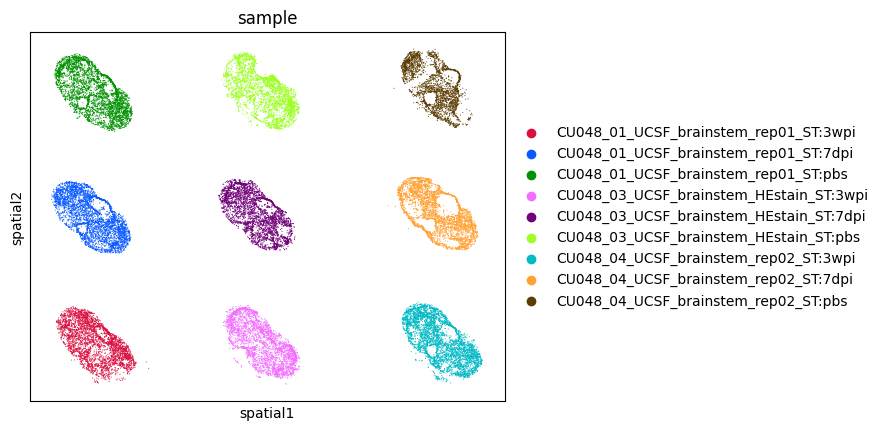

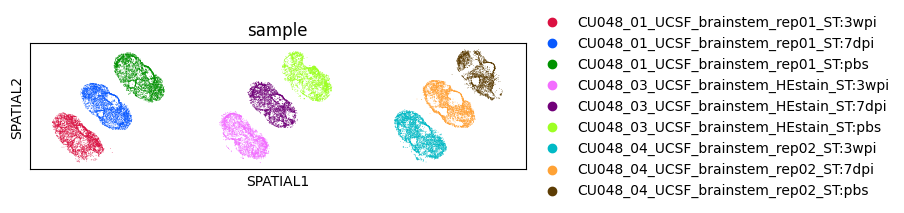

In [5]:
color = "sample"
sc.pl.spatial(
    adata,
    basis="spatial",
    color=color,
    spot_size=50,
    palette=create_palette(len(adata.obs[color].unique())),
)
sc.pl.spatial(
    adata,
    basis="SPATIAL",
    color=color,
    spot_size=50,
    palette=create_palette(len(adata.obs[color].unique())),
)

In [ ]:
sq.gr.spatial_neighbors(adata, spatial_key="spatial")
sq.gr.spatial_autocorr(adata, mode="moran", genes=adata.var_names)
sq.gr.spatial_autocorr(adata, mode="geary", genes=adata.var_names)

In [ ]:
adata.write(DATADIR / "processed" / "external" / "neigborhoods_added.h5ad")

# Compare neighborhood assingments

In [ ]:
adata = sc.read_h5ad(DATADIR / "processed" / "external" / "neigborhoods_added.h5ad")
sq.gr.spatial_neighbors(adata, spatial_key="spatial")
gc.collect()

In [ ]:
import plotly.graph_objects as go
from collections import Counter

cluster_labels1, cluster_labels2 = np.hsplit(
    adata.obs[["cellcharter_k8", "cellcharter_k9"]].values, 2
)
cluster_labels1 = cluster_labels1.flatten()
cluster_labels2 = cluster_labels2.flatten()
N = adata.shape[0]


def cluster_sankey(cluster_labels1, cluster_labels2, name1="", name2="", min_flow=50):
    flow_counts = Counter(zip(cluster_labels1, cluster_labels2))
    flow_counts = {k: v for k, v in flow_counts.items() if v >= min_flow}

    clusters1 = sorted(set(cluster_labels1))
    clusters2 = sorted(set(cluster_labels2))

    source = [clusters1.index(c1) for c1, c2 in flow_counts]
    target = [len(clusters1) + clusters2.index(c2) for c1, c2 in flow_counts]
    value = list(flow_counts.values())

    counts1 = Counter(cluster_labels1)
    counts2 = Counter(cluster_labels2)
    labels = [f"{name1}{c} ({counts1[c]})" for c in clusters1] + [
        f"{name2}{c} ({counts2[c]})" for c in clusters2
    ]

    fig = go.Figure(
        go.Sankey(
            node=dict(label=labels, pad=15, thickness=20),
            link=dict(source=source, target=target, value=value),
        )
    )

    fig.update_layout(title="Cluster Assignment Comparison", font_size=12)
    fig.show()


cluster_sankey(cluster_labels1, cluster_labels2, "K8_", "K9_", N * 0.01)
cluster_sankey(adata.obs["celltype"], adata.obs["cellcharter_k8"])

In [ ]:
s1 = adata[adata.obs["sample"] == adata.obs["sample"].unique()[0]].copy()
sc.pl.spatial(
    s1, basis="spatial", color=["cellcharter_k8", "cellcharter_k9"], spot_size=50
)
adata.obs["temp"] = adata.obs["cellcharter_k8"].isin(["0", "3", "5"])
sc.pl.spatial(s1, basis="spatial", color=["temp"], spot_size=50, title="0/3/5 in K8")
adata.obs["temp"] = adata.obs["cellcharter_k9"].isin(["2", "0", "4", "7", "5"])
sc.pl.spatial(
    s1, basis="spatial", color=["temp"], spot_size=50, title="0/2/4/5/7 in K9"
)
# sc.pl.spatial(s1, basis='spatial', color=['Fos'], spot_size=50, title="0/2/4/5/7 in K9", layer="logcounts", cmap="Blues")

### Spatially variable genes

In [ ]:
# del adata.uns['moranI'], adata.uns["gearyC"]
sq.gr.spatial_autocorr(adata, mode="moran", genes=adata.var_names)
sq.gr.spatial_autocorr(adata, mode="geary", genes=adata.var_names)

adata.uns["moranI"].head(10).index
adata.uns["gearyC"].head(10).index

In [ ]:
moranI = adata.uns["moranI"]
moranI = moranI[
    moranI.index.isin(adata.var[adata.var["n_cells_by_counts"] > min_cells].index)
]

gearyC = adata.uns["moranI"]
gearyC = gearyC[
    gearyC.index.isin(adata.var[adata.var["n_cells_by_counts"] > min_cells].index)
]

# adata.uns["gearyC"].loc[["Chat", "Phox2b"]]
moranI.reset_index()[moranI.index.isin(["Chat", "Phox2b"])]

In [ ]:
top_n = 50
min_cells = 300

moranI = adata.uns["moranI"]
moranI = moranI[
    moranI.index.isin(adata.var[adata.var["n_cells_by_counts"] > min_cells].index)
]
sc.pl.spatial(
    adata[adata.obs["sample"] == adata.obs["sample"].unique()[0]],
    color=moranI.index[:top_n],
    spot_size=50,
    layer="logcounts",
    cmap="Blues",
    ncols=10,
)


gearyC = adata.uns["moranI"]
gearyC = gearyC[
    gearyC.index.isin(adata.var[adata.var["n_cells_by_counts"] > min_cells].index)
]
sc.pl.spatial(
    adata[adata.obs["sample"] == adata.obs["sample"].unique()[0]],
    color=gearyC.index[:top_n],
    spot_size=50,
    layer="logcounts",
    cmap="Blues",
    ncols=10,
)

### Neighborhood Enrichment Matrix
What is close to what? 

In [ ]:
adjacencies = [
    "celltype",
    "BANKSY_labels_scaled_gaussian_pc30_nc0.50_r0.40",
    "cellcharter_k8",
]
run = True
if run is True:
    for cluster in adjacencies:
        sq.gr.nhood_enrichment(adata, cluster_key=cluster)

f = plt.figure(figsize=(10, 15), layout="constrained")
sf = f.subfigures(1, 2, width_ratios=[3, 1])
axs1 = sf[0].subplots(3, 1)
axs2 = sf[1].subplots(3, 1)

for i, cluster in enumerate(adjacencies):
    sc.pl.spatial(
        adata, basis="spatial", color=cluster, spot_size=50, ax=axs1[i], show=False
    )
    sq.pl.nhood_enrichment(
        adata, cluster_key=cluster, ax=axs2[i], normalize=True, cmap="Blues"
    )
f.suptitle("Neigborhood enrichment")

In [ ]:
# neighborhood composition
group = adjacencies[2]
celltype = "seurat_clusters"

f = plt.figure(figsize=(10, 10), layout="constrained")
axs = f.subplots(2, 2)
axs = axs.flatten()
plot_cluster_stackedbarplot(adata, group, celltype, pct=False, ax=axs[0])
plot_cluster_stackedbarplot(adata, group, celltype, pct=True, ax=axs[1])
plot_cluster_stackedbarplot(adata, celltype, group, pct=False, ax=axs[2])
plot_cluster_stackedbarplot(adata, celltype, group, pct=True, ax=axs[3])


crosstab = pd.crosstab(adata.obs[celltype], adata.obs[group]).astype(int)
f, axs = plt.subplots(1, 2, figsize=(16, 8), layout="constrained")
sns.heatmap(
    crosstab.div(crosstab.sum(axis=1), axis=0),
    cmap="Reds",
    annot=crosstab,
    fmt="d",
    ax=axs[0],
)
axs[0].set_title("Normalized by row (per celltype)", size=12)

sns.heatmap(
    crosstab.div(crosstab.sum(axis=0), axis=1),
    cmap="Reds",
    annot=crosstab,
    fmt="d",
    ax=axs[1],
)
axs[1].set_title("normalized by column (per neighborhood)", size=12)
f.suptitle("Percent Celltypes by Neighorhood (count annotated)", size=18)


sc.pl.spatial(
    adata[adata.obs["sample"] == adata.obs["sample"].unique()[0]],
    basis="spatial",
    color=adjacencies[2],
    spot_size=50,
    title=f"{adata.obs['sample'].unique()[0]} ({adjacencies[2]})",
)

In [ ]:
tmp = adata[adata.obs["seurat_clusters"] == "12"]
sc.tl.rank_genes_groups(
    tmp,
    groupby=f"cellcharter_k8",
    use_raw=False,
    groups=["6", "7"],
    layer="logcounts",
    method="wilcoxon",
)
sc.pl.rank_genes_groups(tmp)
sc.pl.spatial(
    adata[adata.obs["sample"] == adata.obs["sample"].unique()[0]],
    color=["Scg2", "Hoxa5"],
    spot_size=50,
    layer="logcounts",
    cmap="Blues",
)

In [ ]:
adata.obs["banksy_plot"] = adata.obs[adjacencies[1]]
group = "banksy_plot"
celltype = adjacencies[0]

f = plt.figure(figsize=(10, 10), layout="constrained")
axs = f.subplots(2, 2)
axs = axs.flatten()
plot_cluster_stackedbarplot(adata, group, celltype, pct=False, ax=axs[0])
plot_cluster_stackedbarplot(adata, group, celltype, pct=True, ax=axs[1])
plot_cluster_stackedbarplot(adata, celltype, group, pct=False, ax=axs[2])
plot_cluster_stackedbarplot(adata, celltype, group, pct=True, ax=axs[3])


crosstab = pd.crosstab(adata.obs[celltype], adata.obs[group]).astype(int)
f, axs = plt.subplots(1, 2, figsize=(16, 8), layout="constrained")
sns.heatmap(
    crosstab.div(crosstab.sum(axis=1), axis=0),
    cmap="Reds",
    annot=crosstab,
    fmt="d",
    ax=axs[0],
)
axs[0].set_title("Normalized by row (per celltype)", size=12)

sns.heatmap(
    crosstab.div(crosstab.sum(axis=0), axis=1),
    cmap="Reds",
    annot=crosstab,
    fmt="d",
    ax=axs[1],
)
axs[1].set_title("normalized by column (per neighborhood)", size=12)
f.suptitle("Percent Celltypes by Neighorhood (count annotated)", size=18)

sc.pl.spatial(
    adata[adata.obs["sample"] == adata.obs["sample"].unique()[0]],
    basis="spatial",
    color="banksy_plot",
    spot_size=50,
    title=f"{adata.obs['sample'].unique()[0]} (banksy_plot)",
)

### Co-occurrence Plots
Probability of finding a cluster as you go a further distance from **one specific cluster of interest**.
* This has to be done on a per-sample basis.

In [ ]:
run = True
if run is True:
    warnings.filterwarnings("ignore")
    split_adatas = []
    for sample in adata.obs["sample"].unique():
        tmp = adata[adata.obs["sample"] == sample].copy()
        sq.gr.co_occurrence(
            tmp,
            spatial_key="SPATIAL",
            n_jobs=CORES,
            cluster_key="celltype",
            show_progress_bar=False,
        )
        split_adatas.append(tmp)

for tmp in split_adatas:
    sq.pl.co_occurrence(
        tmp, cluster_key="celltype", clusters=tmp.obs["celltype"].unique()
    )

In [ ]:
sq.pl.co_occurrence(
    split_adatas[0], cluster_key="celltype", clusters=tmp.obs["celltype"].unique()
)

# Exploratory

[<Axes: title={'center': 'sample'}, xlabel='spatial1', ylabel='spatial2'>]

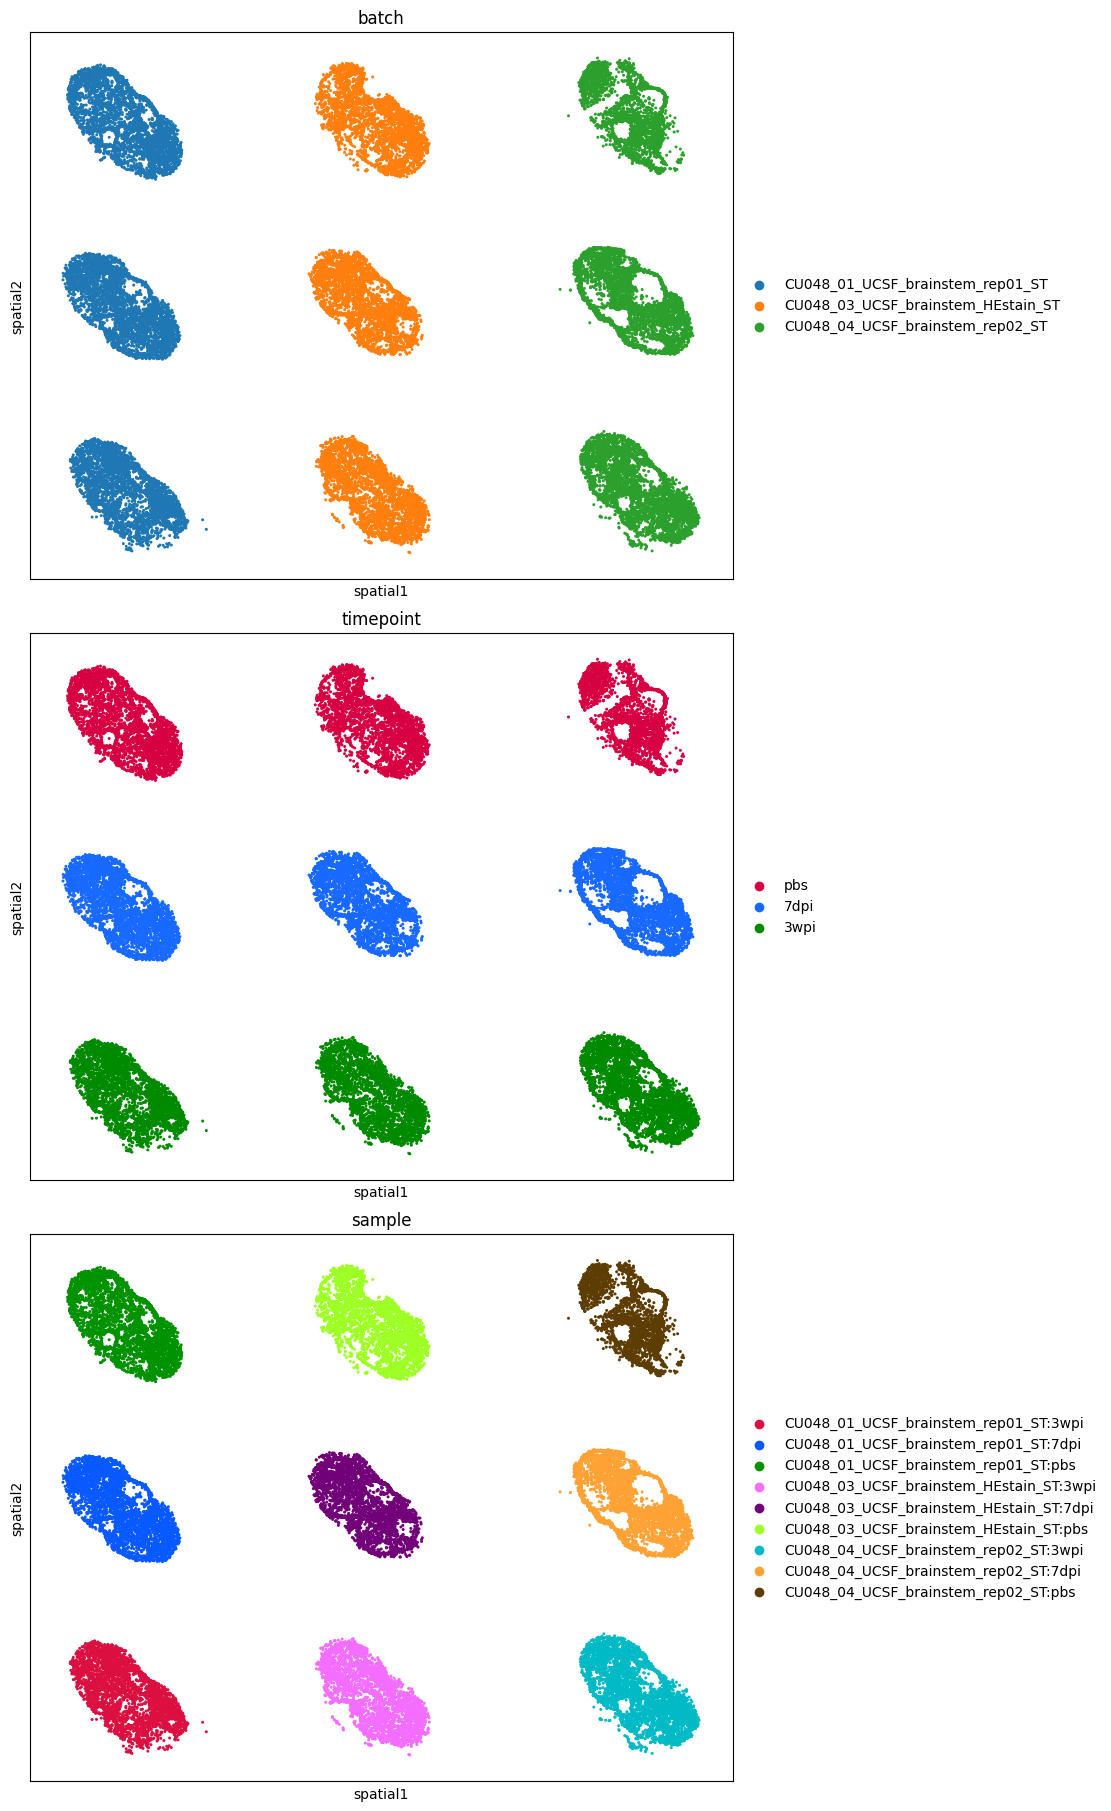

In [31]:
# adata = sc.read_h5ad(DATADIR / "processed" / "external" / "neigborhoods_added.h5ad")
clear_uns(adata, "colors")

f, ax = plt.subplots(3, 1, figsize=(15, 18), layout="constrained")
sc.pl.spatial(
    adata, basis="spatial", color="batch", spot_size=100, ax=ax[0], show=False
)
sc.pl.spatial(
    adata,
    basis="spatial",
    color="timepoint",
    spot_size=100,
    ax=ax[1],
    show=False,
    palette=create_palette(3) + ["#000000"],
)
sc.pl.spatial(
    adata,
    basis="spatial",
    color="sample",
    spot_size=100,
    ax=ax[2],
    show=False,
    palette=create_palette(len(adata.obs["sample"].unique())),
)

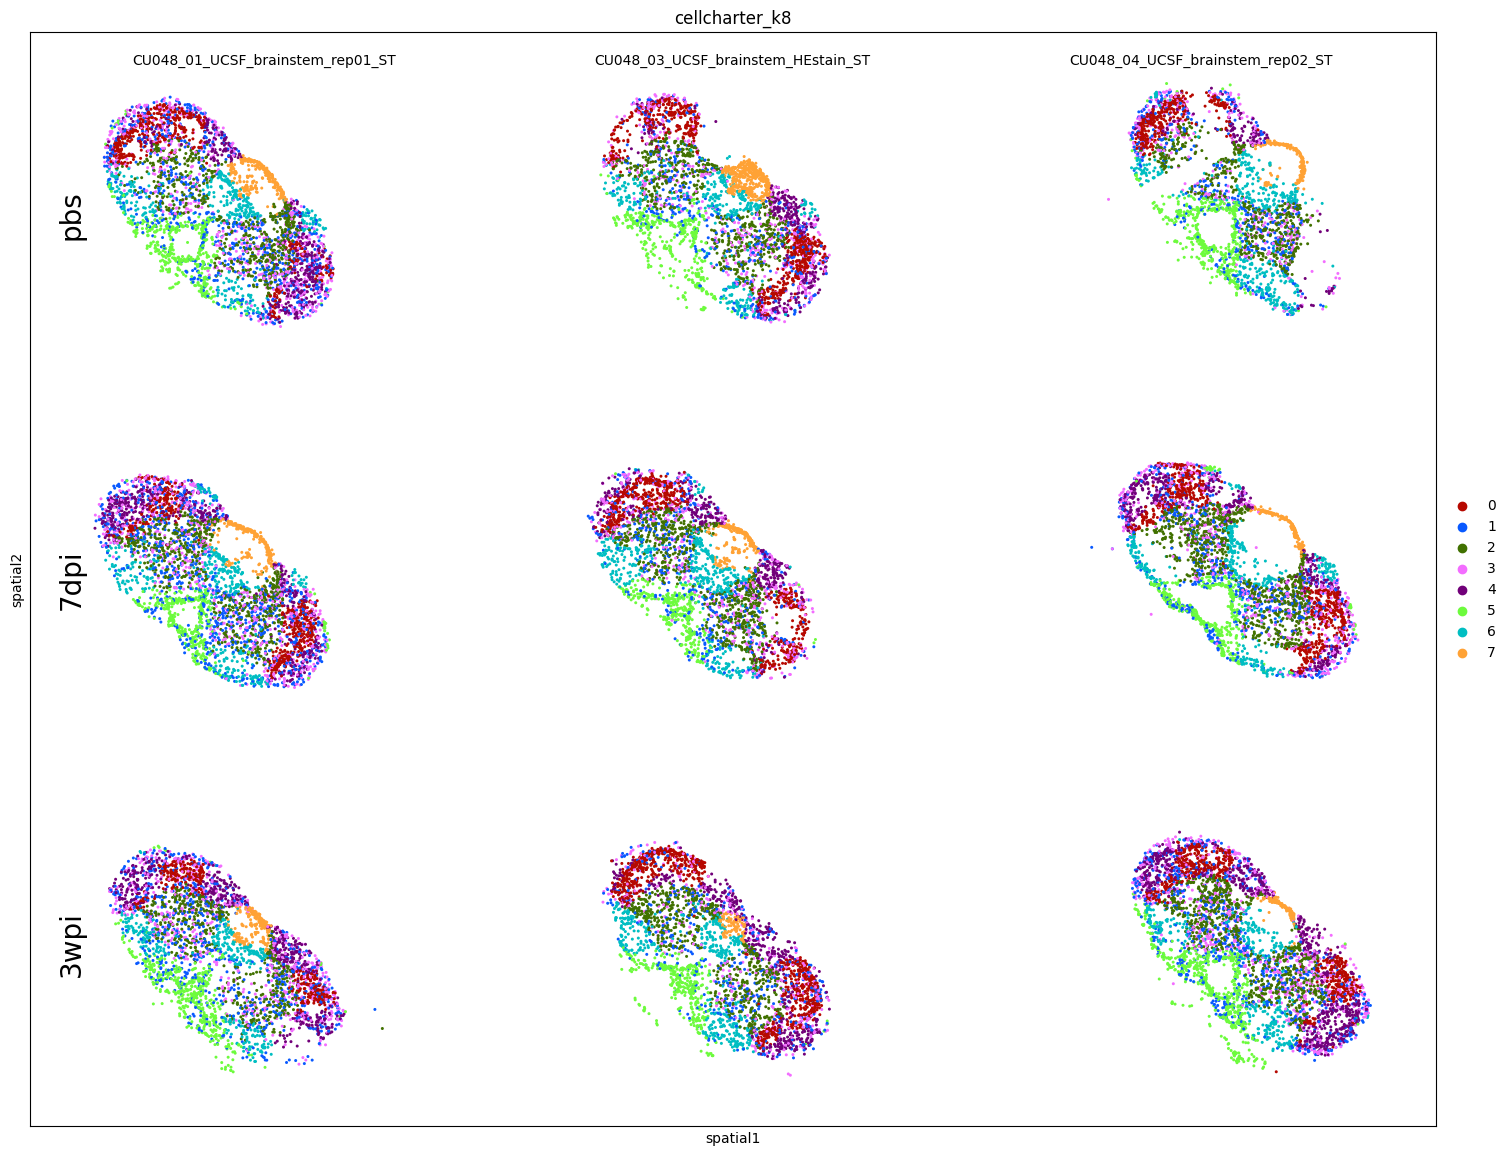

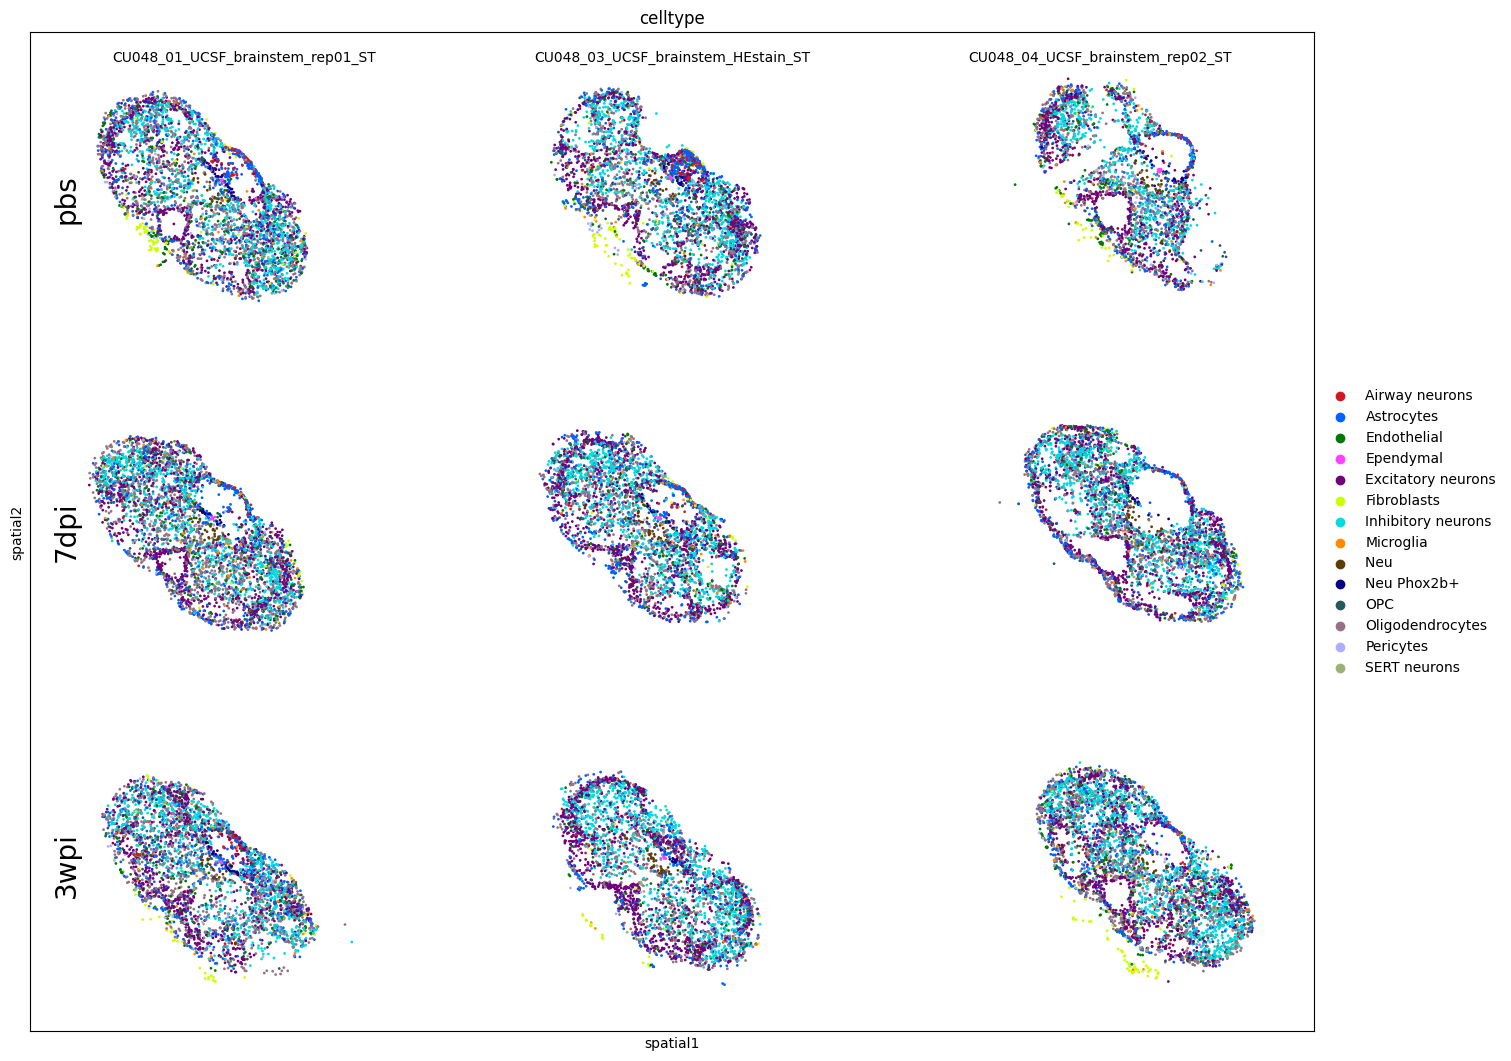

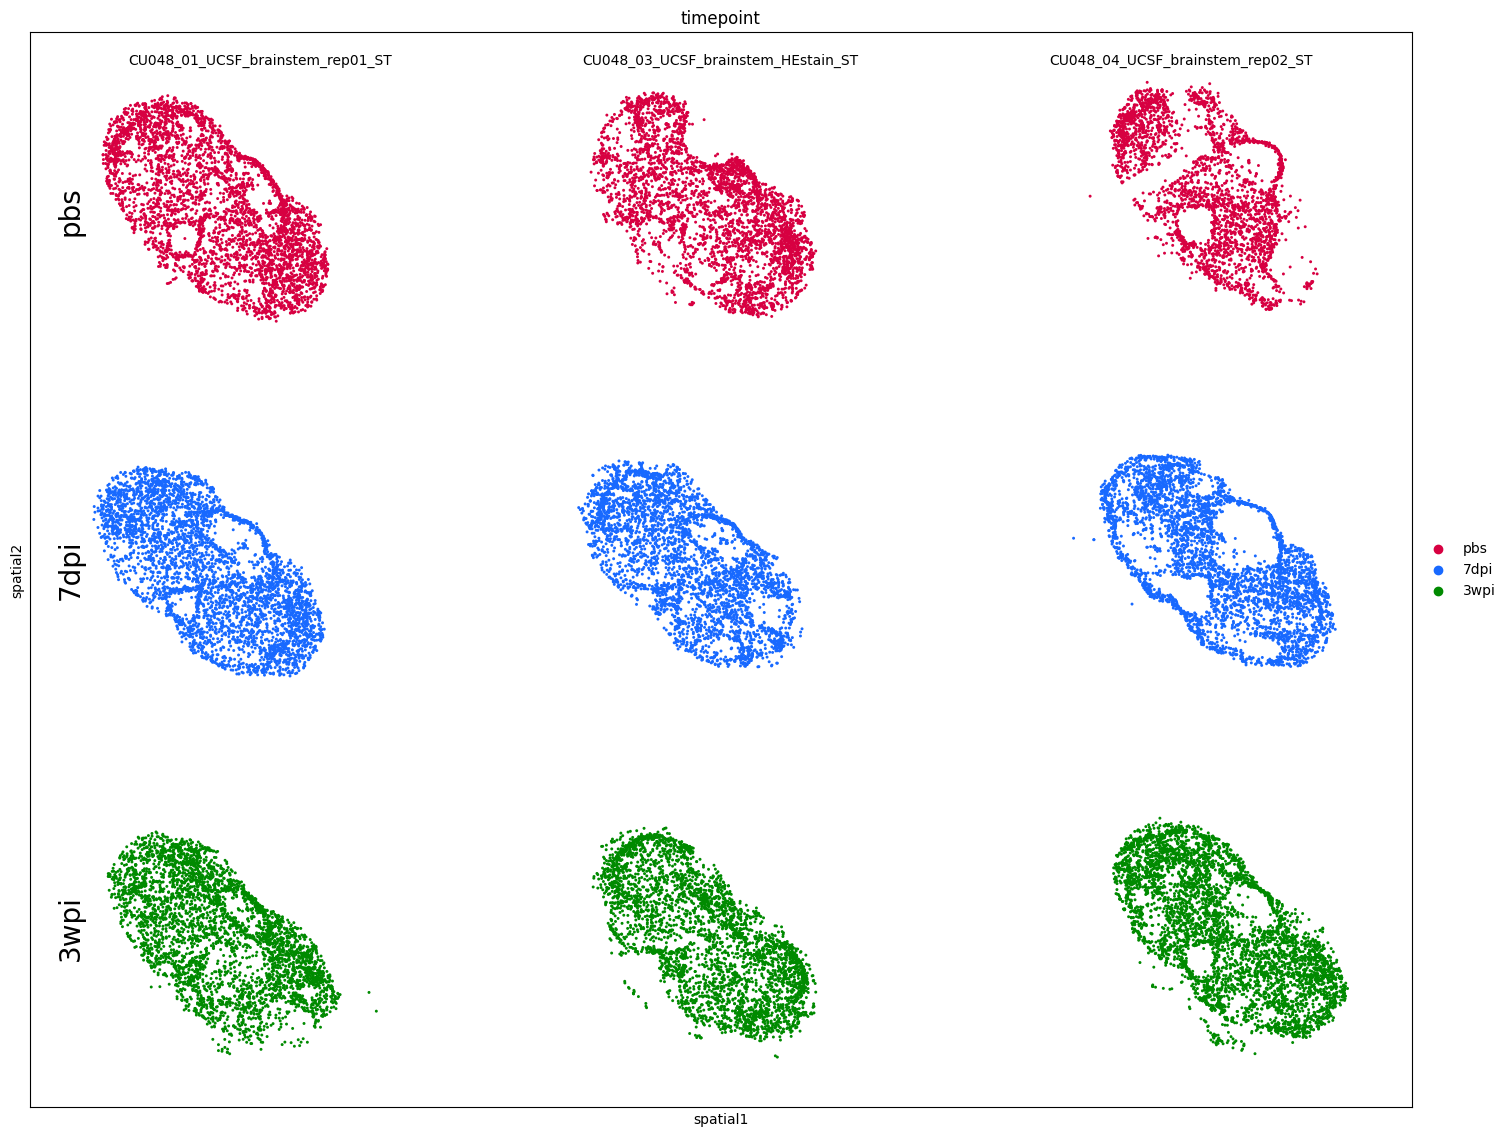

In [45]:
f, ax = plt.subplots(1, 1, figsize=(15, 15), layout="constrained")
sc.pl.spatial(adata, basis="spatial", color="cellcharter_k8", spot_size=50, ax=ax, show=False)
AddPailinLabels(ax, adata, 20)

f, ax = plt.subplots(1, 1, figsize=(15, 15), layout="constrained")
sc.pl.spatial(adata, basis="spatial", color="celltype", spot_size=50, ax=ax, show=False)
AddPailinLabels(ax, adata, 20)

f, ax = plt.subplots(1, 1, figsize=(15, 15), layout="constrained")
sc.pl.spatial(adata, basis="spatial", color="timepoint", spot_size=50, ax=ax, show=False)
AddPailinLabels(ax, adata, 20)

<Axes: title={'center': 'timepoint'}, xlabel='UMAP_SCT1', ylabel='UMAP_SCT2'>

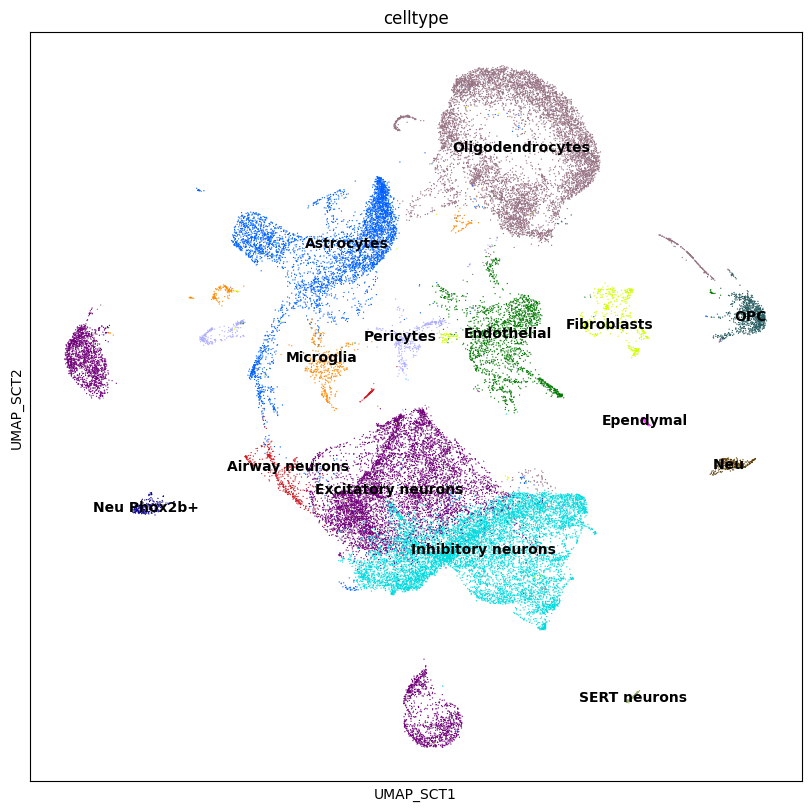

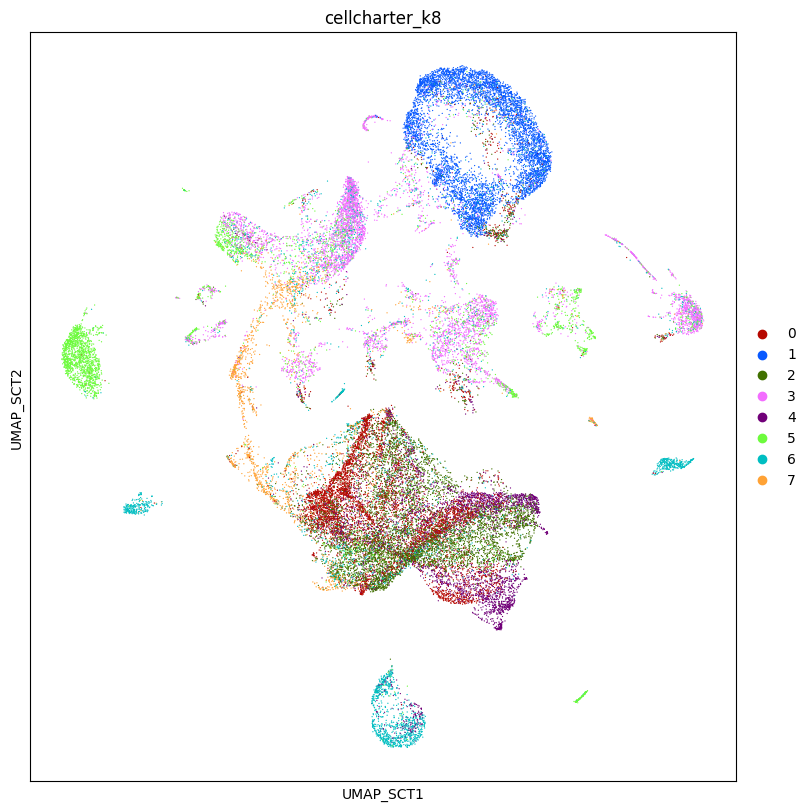

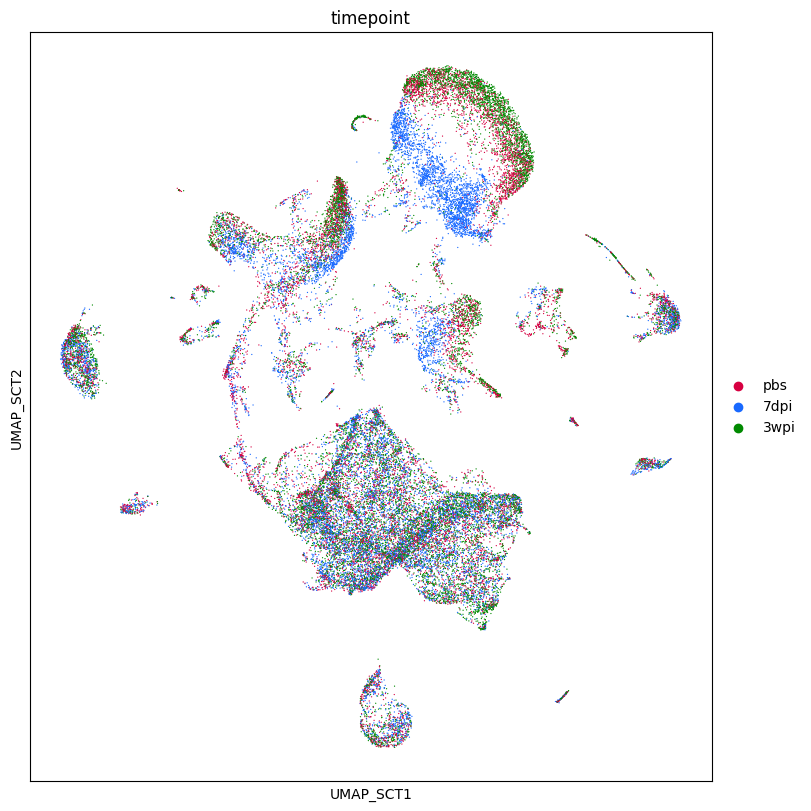

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(8, 8), layout="constrained")
sc.pl.embedding(
    adata, basis="UMAP_SCT", color="celltype", ax=ax, show=False, legend_loc="on data", palette=color_gen(adata.obs["celltype"])
)

f, ax = plt.subplots(1, 1, figsize=(8, 8), layout="constrained")
sc.pl.embedding(
    adata, basis="UMAP_SCT", color="cellcharter_k8", ax=ax, show=False, palette=color_gen(adata.obs["cellcharter_k8"])
)

f, ax = plt.subplots(1, 1, figsize=(8, 8), layout="constrained")
sc.pl.embedding(
    adata, basis="UMAP_SCT", color="timepoint", ax=ax, show=False, palette=color_gen(adata.obs["timepoint"])
)

In [47]:
f.get_axes()

[<Axes: xlabel='celltype'>]

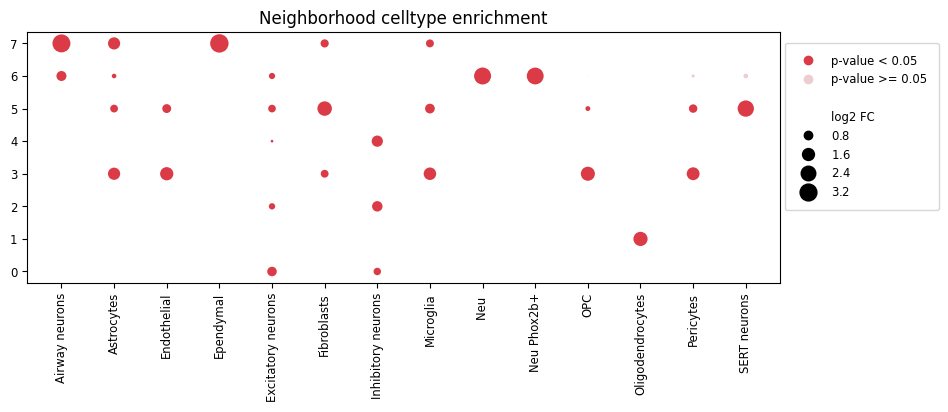

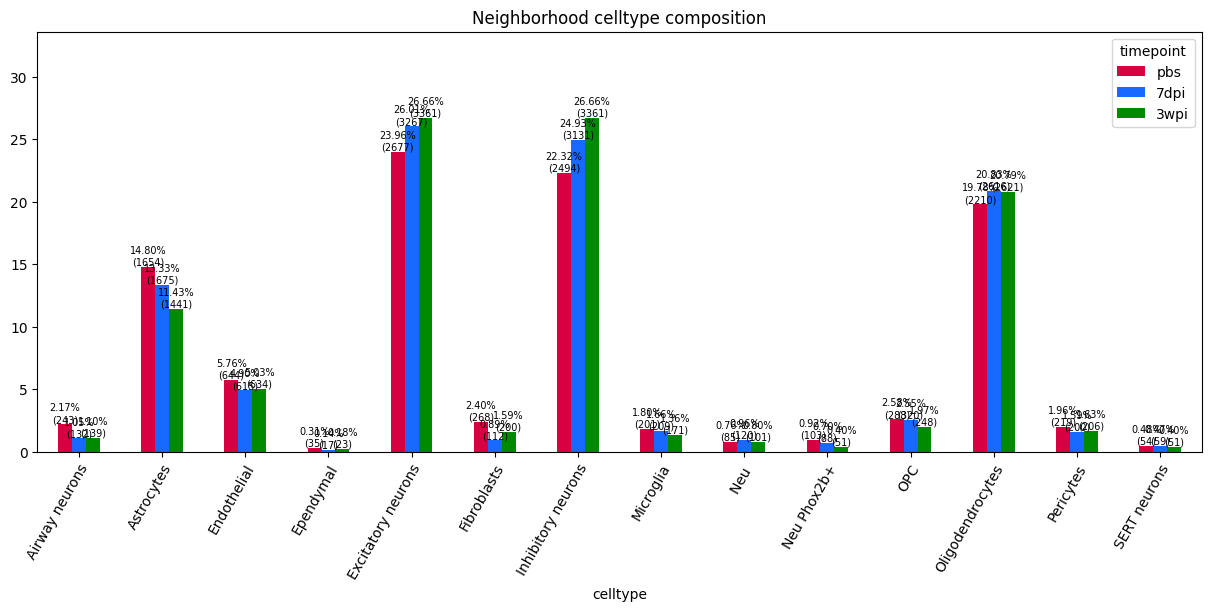

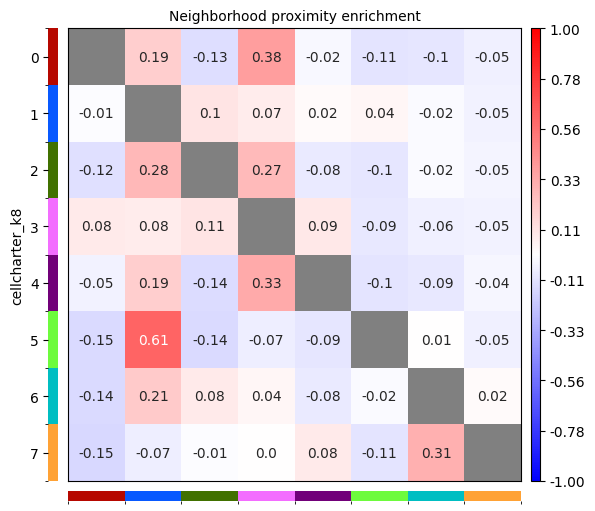

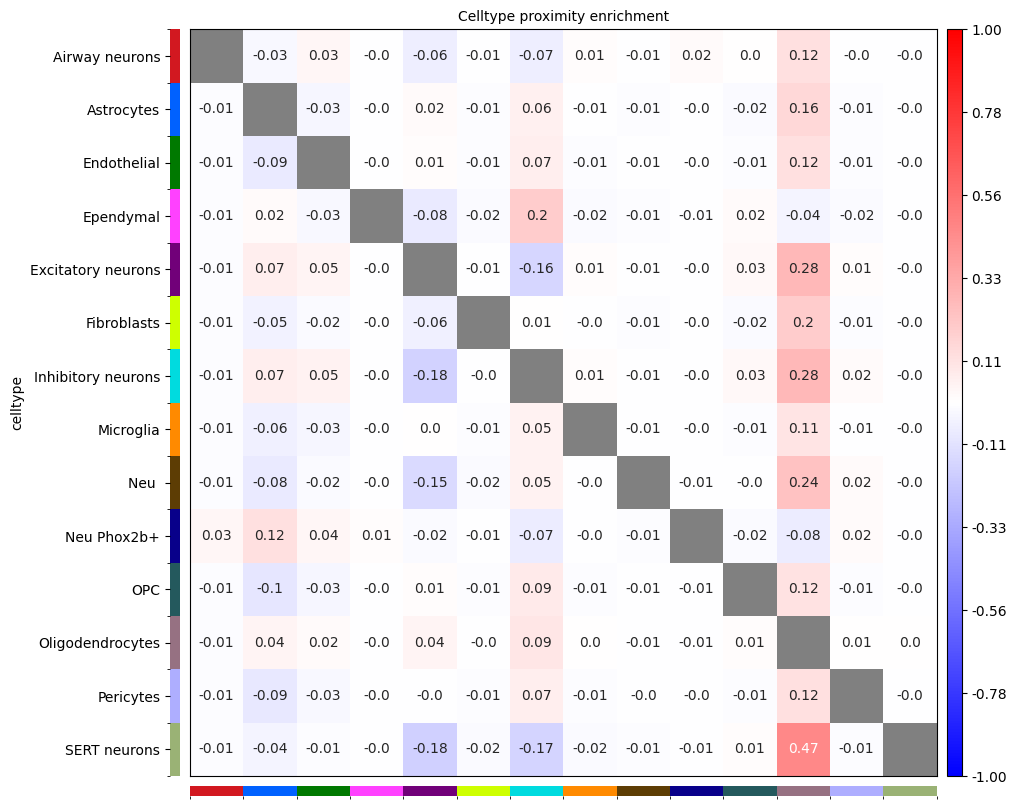

In [48]:
RUN = False

if RUN is True: cc.gr.enrichment(adata, group_key="cellcharter_k8", label_key="celltype", pvalues=True)
cc.pl.enrichment(
    adata, group_key="cellcharter_k8", label_key="celltype", figsize=(8, 4), group_cluster=False, show_pvalues=True, significance=0.05
)
plt.title("Neighborhood celltype enrichment")

f = plt.figure(figsize=(12,6), layout="constrained")
plot_cluster_barplots(adata, "timepoint", "celltype", f)
f.get_axes()[0].set_title("Neighborhood celltype composition")

if RUN is True: cc.gr.nhood_enrichment(adata, cluster_key="cellcharter_k8")
cc.pl.nhood_enrichment(
    adata,
    cluster_key="cellcharter_k8",
    annotate=True,
    vmin=-1,
    vmax=1,
    figsize=(5, 5),
    title = "Neighborhood proximity enrichment"
)

if RUN is True: cc.gr.nhood_enrichment(adata, cluster_key="celltype")
cc.pl.nhood_enrichment(
    adata,
    cluster_key="celltype",
    annotate=True,
    vmin=-1,
    vmax=1,
    figsize=(8, 8),
    title = "Celltype proximity enrichment"
)

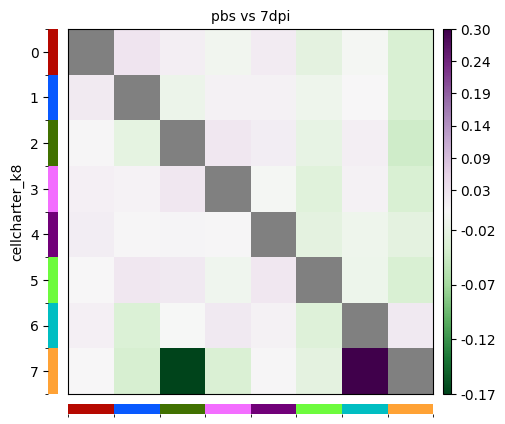

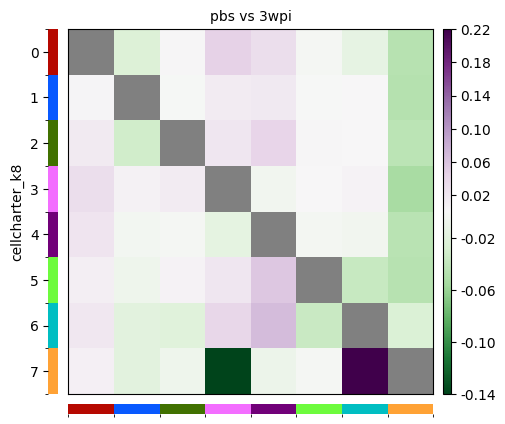

In [22]:
# cc.gr.diff_nhood_enrichment(
#     adata,
#     cluster_key='cellcharter_k8',
#     condition_key='timepoint',
#     library_key='batch',
#     pvalues=True,
#     n_jobs=20,
#     n_perms=100
# )
for tp in adata.obs["timepoint"].unique():
    if tp != "pbs":
        cc.pl.diff_nhood_enrichment(
            adata,
            cluster_key='cellcharter_k8',
            condition_key='timepoint',
            condition_groups=['pbs', tp],
            annotate=True,
            figsize=(5,5),
            significance=0.05,
            fontsize=10
        )

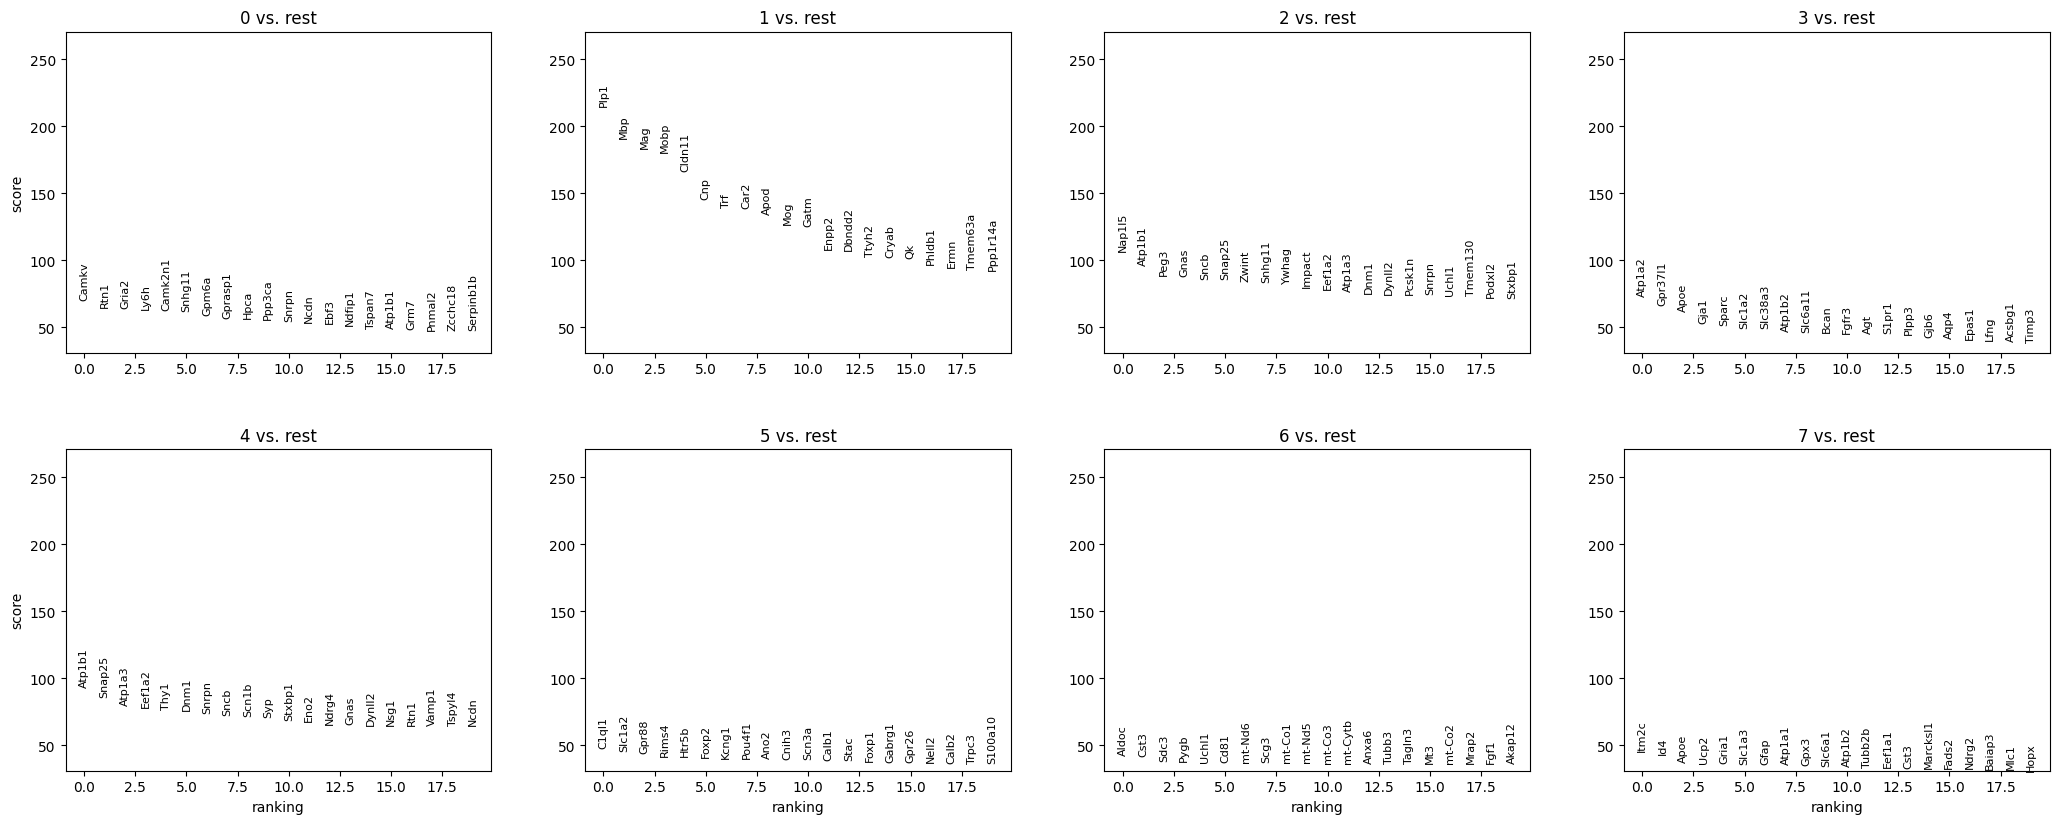

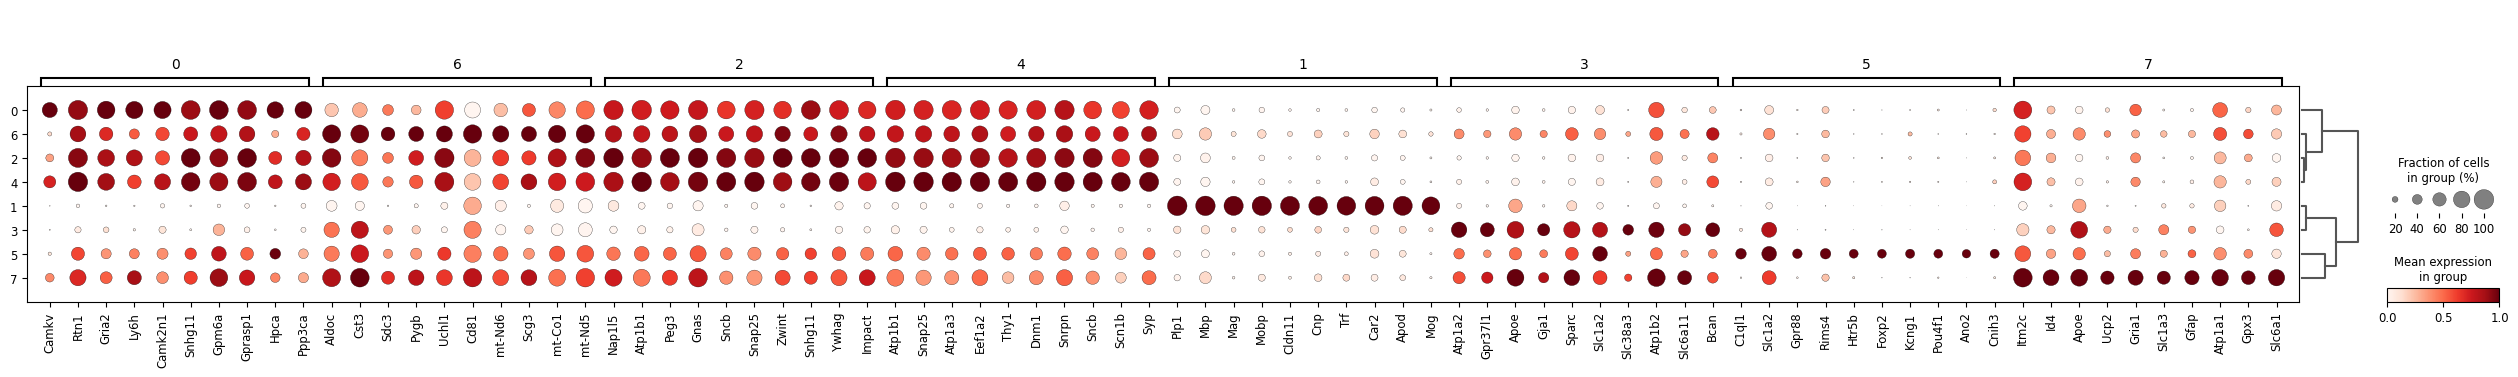

In [59]:
# DEGs by neighborhood
deg_key = "DEGs_cck8"
cluster = "cellcharter_k8"
run = False

if run is True:
    sc.tl.rank_genes_groups(
        adata, groupby=cluster, key_added=deg_key, layer="normalized"
    )

sc.pl.rank_genes_groups(adata, groupby=cluster, key=deg_key)
sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby=cluster,
    key=deg_key,
    n_genes=10,
    standard_scale="var",
    layer="normalized",
)

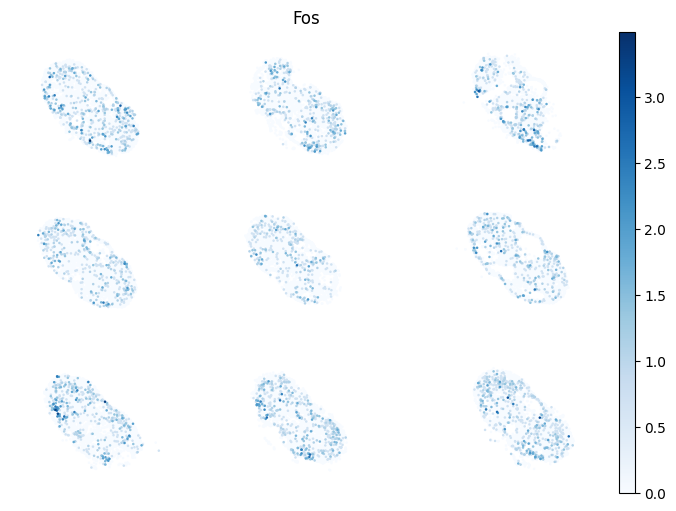

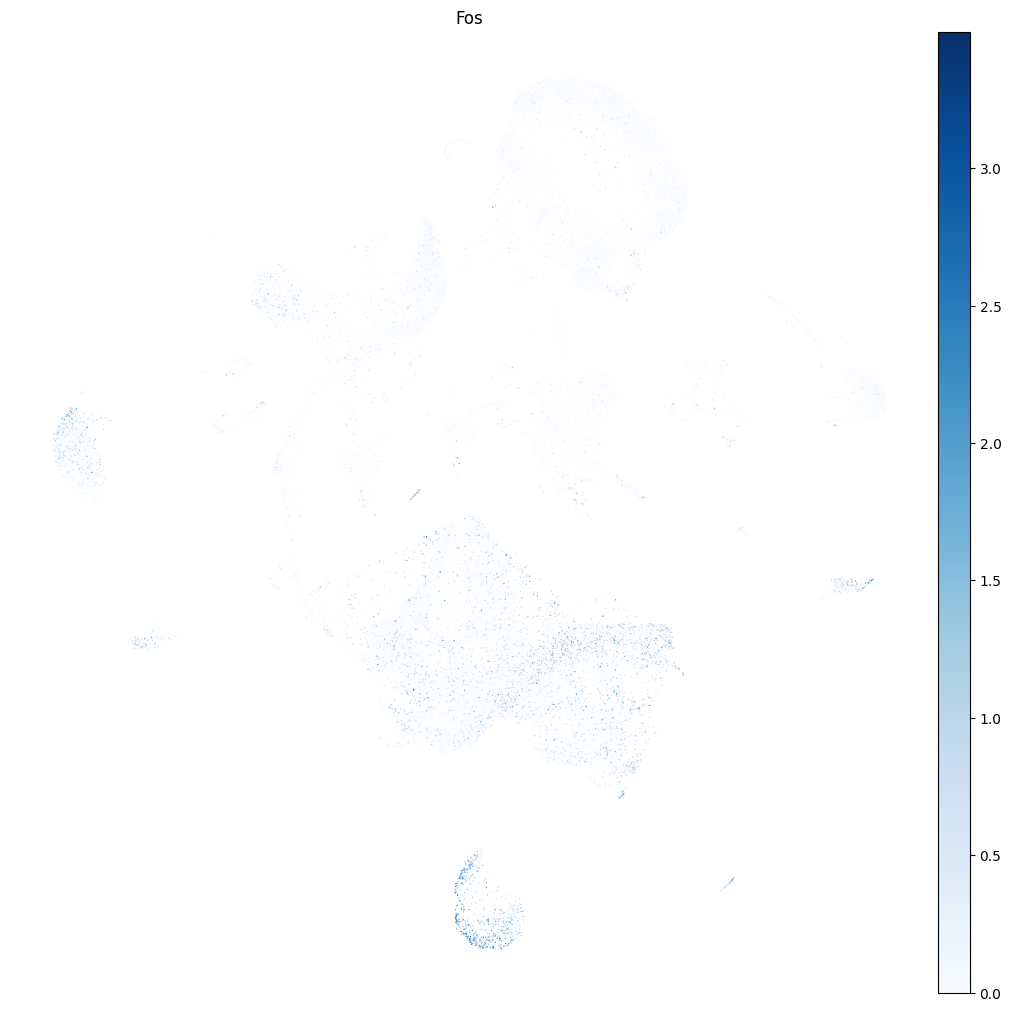

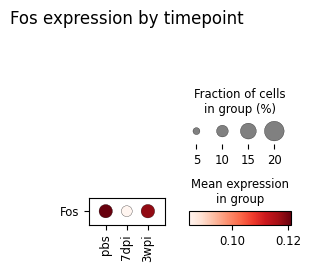

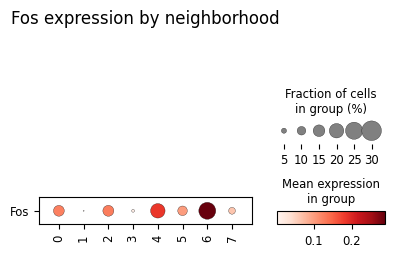

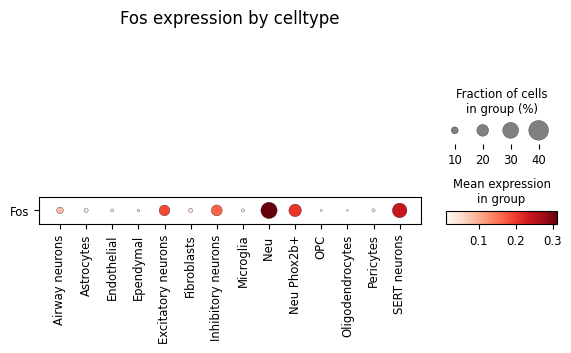

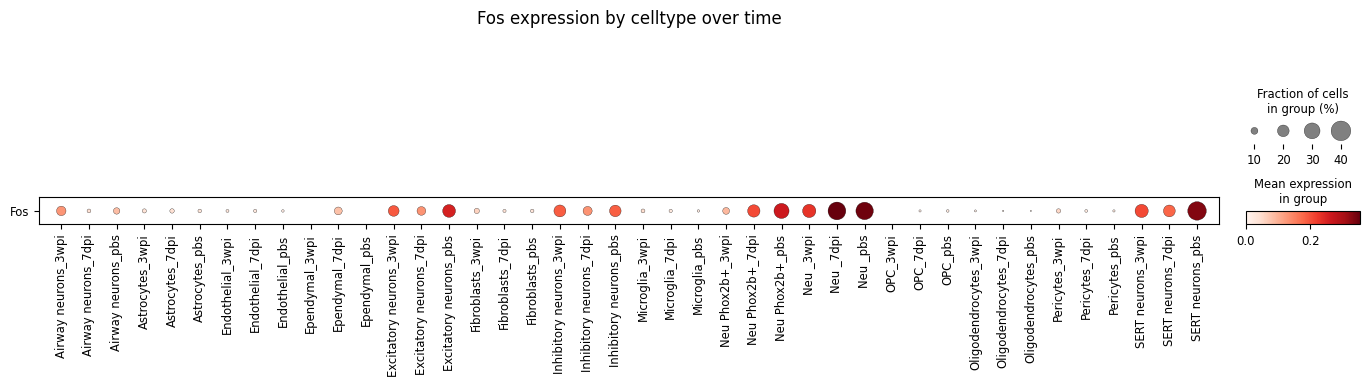

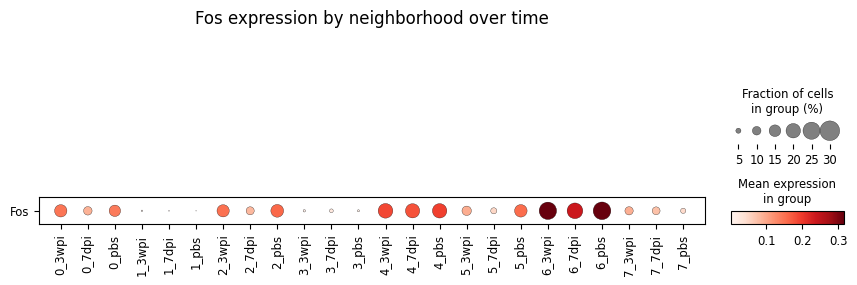

In [63]:
# Fos by grouping

f, ax = plt.subplots(1, 1, figsize=(18, 5), layout="constrained")
sc.pl.spatial(
    adata,
    basis="spatial",
    color="Fos",
    spot_size=100,
    frameon=False,
    layer="normalized",
    cmap="Blues",
    ax=ax,
)

f, ax = plt.subplots(1, 1, figsize=(10, 10), layout="constrained")
sc.pl.embedding(
    adata,
    basis="UMAP_SCT",
    color="Fos",
    frameon=False,
    layer="normalized",
    cmap="Blues",
    ax=ax,
)

sc.pl.dotplot(
    adata,
    var_names="Fos",
    groupby=["timepoint"],
    swap_axes=True,
    title="Fos expression by timepoint",
    layer="normalized",
)
sc.pl.dotplot(
    adata,
    var_names="Fos",
    groupby=["cellcharter_k8"],
    swap_axes=True,
    title="Fos expression by neighborhood",
    layer="normalized",
)
sc.pl.dotplot(
    adata,
    var_names="Fos",
    groupby=["celltype"],
    swap_axes=True,
    title="Fos expression by celltype",
    layer="normalized",
)

sc.pl.dotplot(
    adata,
    var_names="Fos",
    groupby=["celltype.timepoint"],
    swap_axes=True,
    title="Fos expression by celltype over time",
    layer="normalized",
)

sc.pl.dotplot(
    adata,
    var_names="Fos",
    groupby=["neighborhood.timepoint"],
    swap_axes=True,
    title="Fos expression by neighborhood over time",
    layer="normalized",
)

# IFN module scores (11/13)

In [ ]:
import pyucell as uc

adata.X = adata.layers["logcounts"].copy()

rmj_genelist = (
    pd.read_csv(REFDIR / "pailin_references" / "RMJ_MERFISH.csv").iloc[:, 1].values
)
rmj_genelist = [gene for gene in rmj_genelist if gene in adata.var_names]

hobson_genelist = pd.read_csv(
    REFDIR / "pailin_references" / "Hobson BBI 2023 Bulk RNAseq DEGs.csv"
)
hobson_genelist = hobson_genelist[
    hobson_genelist["Contrast"] == "NeuPos_IFN-v-Sal_48h"
].sort_values("padj")
hobson_genelist = hobson_genelist[hobson_genelist["padj"] < 0.05]["gene_name"].values

sc.tl.score_genes(adata, rmj_genelist, score_name="RMJ_score_Seurat")
sc.tl.score_genes(adata, hobson_genelist, score_name="Hobson_score_Seurat")

uc.compute_ucell_scores(
    adata, signatures={"RMJ_score": rmj_genelist, "Hobson_score": hobson_genelist}
)

gc.collect()

In [ ]:
scores_cols = [
    f"{dataset}_score_{method}"
    for method in ["UCell", "Seurat"]
    for dataset in ["RMJ", "Hobson"]
]
f = plt.figure(figsize=(12, 10), layout="constrained")
plot_violinplot(
    adata, group="celltype.timepoint", markers=scores_cols, f=f, useStripPlot=False
)
axs = f.get_axes()
for ax in axs:
    ax.axhline(0, color="black")

f = plt.figure(figsize=(12, 10), layout="constrained")
plot_violinplot(
    adata, group="neighborhood.timepoint", markers=scores_cols, f=f, useStripPlot=False
)
axs = f.get_axes()
for ax in axs:
    ax.axhline(0, color="black")

gc.collect()

In [ ]:
scores_cols = [
    f"{dataset}_score_{method}"
    for dataset in ["RMJ", "Hobson"]
    for method in ["UCell", "Seurat"]
]

# Fos by grouping
sc.pl.matrixplot(
    adata, var_names=scores_cols, groupby="timepoint", standard_scale="var"
)
sc.pl.matrixplot(
    adata, var_names=scores_cols, groupby="cellcharter_k8", standard_scale="var"
)
sc.pl.matrixplot(
    adata,
    var_names=scores_cols,
    groupby=["cellcharter_k8", "timepoint"],
    standard_scale="var",
)
sc.pl.matrixplot(adata, var_names=scores_cols, groupby="celltype", standard_scale="var")
sc.pl.matrixplot(
    adata,
    var_names=scores_cols,
    groupby=["celltype", "timepoint"],
    standard_scale="var",
)

# # Fos by grouping
# sc.pl.matrixplot(adata, var_names=scores_cols, groupby="timepoint")
# sc.pl.matrixplot(adata, var_names=scores_cols, groupby="cellcharter_k8")
# sc.pl.matrixplot(adata, var_names=scores_cols, groupby=["cellcharter_k8", "timepoint"])
# sc.pl.matrixplot(adata, var_names=scores_cols, groupby="celltype")
# sc.pl.matrixplot(adata, var_names=scores_cols, groupby=["celltype", "timepoint"])

gc.collect()

In [ ]:
scores_cols = [
    f"{dataset}_score_{method}"
    for method in ["UCell", "Seurat"]
    for dataset in ["RMJ", "Hobson"]
]

r, c = 2, 2
f, axs = plt.subplots(r, c, figsize=(c * 8, r * 6), layout="constrained")
axs = axs.flatten()
f.suptitle("Score Distribution")
for i, col in enumerate(scores_cols):
    sns.histplot(adata.obs[col], ax=axs[i])

In [ ]:
from scipy.stats import zscore

scores_cols = [
    f"{dataset}_score_{method}"
    for dataset in ["RMJ", "Hobson"]
    for method in ["Seurat", "UCell"]
]

print(adata.obs["sample"].cat.categories)
samp1 = "CU048_01_UCSF_brainstem_rep01_ST:3wpi"

r, c = 3, 2
f, axs = plt.subplots(r, c, figsize=(c * 8, r * 6), layout="constrained")
axs = axs.flatten()
f.suptitle(samp1)
for i, col in enumerate(scores_cols):
    adata.obs["temp_plot"] = zscore(adata.obs[col])
    subset = adata[adata.obs["sample"] == samp1]
    sc.pl.embedding(
        subset,
        "spatial",
        color=["temp_plot"],
        cmap="RdBu_r",
        title=col,
        ax=axs[i],
        show=False,
        vcenter=0,
        vmax=3,
        vmin=-3,
    )
sc.pl.embedding(subset, "spatial", color=["cellcharter_k8"], ax=axs[-2], show=False)
sc.pl.embedding(subset, "spatial", color=["celltype"], ax=axs[-1], show=False)

In [ ]:
r, c = 3, 2
f, axs = plt.subplots(r, c, figsize=(c * 8, r * 6), layout="constrained")
axs = axs.flatten()
for i, col in enumerate(scores_cols):
    adata.obs["temp_plot"] = zscore(adata.obs[col])
    sc.pl.embedding(
        adata,
        "UMAP_SCT",
        color="temp_plot",
        cmap="RdBu_r",
        title=col,
        ax=axs[i],
        show=False,
        vcenter=0,
    )

sc.pl.embedding(
    adata, "UMAP_SCT", color="cellcharter_k8", title=col, ax=axs[-2], show=False
)
sc.pl.embedding(adata, "UMAP_SCT", color="celltype", title=col, ax=axs[-1], show=False)

In [ ]:
adata.write(DATADIR / "processed" / "external" / "neighborhood_analyzed.h5ad")

# Requested Plots 12/10
- change cell definitions to original ones

how are other cells interacting with Fos+ NTS neuron
- DEGs by timepoint, per celltype (e.g. like Fos+ only)
- colocalization of cells + celltype communication + neighborhood coenrichment
- focus on 6 & 7

### Object Updates

In [ ]:
adata = sc.read_h5ad(DATADIR / "processed" / "external" / "neigborhoods_added.h5ad")
adata.layers["normalized"] = adata.layers["logcounts"].copy()
del adata.layers["logcounts"]

adata.obs["sample"] = adata.obs["sample"].astype("category")
order_obs(adata, "timepoint", order=["pbs", "7dpi", "3wpi"])
clear_uns(adata, "colors")

celltype_mapping = {
    0: "Inhibitory neurons",
    1: "Excitatory neurons",
    2: "Astrocytes",
    3: "Oligodendrocytes",
    4: "Endothelial",
    5: "Oligodendrocytes",
    6: "Excitatory neurons",
    7: "Excitatory neurons",
    8: "Microglia",
    9: "Pericytes",
    10: "OPC",
    11: "Fibroblasts",
    12: "Airway neurons",
    13: "Astrocytes",
    14: "Neu ",
    15: "Neu Phox2b+",
    16: "Oligodendrocytes",
    17: "SERT neurons",
    18: "Ependymal",
}
adata.obs["celltype"] = (
    adata.obs["seurat_clusters"].astype(int).map(celltype_mapping).astype("category")
)

adata.obs["celltype.timepoint"] = (
    adata.obs["celltype"].astype(str) + "_" + adata.obs["timepoint"].astype(str)
)
adata.obs["celltype.timepoint"] = adata.obs["celltype.timepoint"].astype("category")

adata.obs["neighborhood.timepoint"] = (
    adata.obs["cellcharter_k8"].astype(str) + "_" + adata.obs["timepoint"].astype(str)
)
adata.obs["neighborhood.timepoint"] = adata.obs["neighborhood.timepoint"].astype(
    "category"
)

adata

In [ ]:
# Add SCT Information

R_preload()
with ro.conversion.localconverter(converter):
    ro.r(
        """
    Seurat_obj <- readRDS(file = '../../../data/processed/external/CU048_ConfPositioned_seurat_spatial_merged.rds')
    DefaultAssay(Seurat_obj) <- 'SCT'
    sce_SCT <- as.SingleCellExperiment(Seurat_obj)
    pca_embed <- Embeddings(Seurat_obj, reduction = "pca")
    umap_embed <- Embeddings(Seurat_obj, reduction = "umap")
    """
    )
    adata_SCT = ro.globalenv["sce_SCT"]
    adata_SCT.obsm["PCA_SCT"] = ro.globalenv["pca_embed"]
    adata_SCT.obsm["UMAP_SCT"] = ro.globalenv["umap_embed"]

adata_SCT = adata_SCT[adata.obs_names]

adata.obsm["SCT_raw"] = adata_SCT.X.copy()
adata.obsm["SCT_log"] = adata_SCT.layers["logcounts"].copy()
adata.obsm["PCA_SCT"] = adata_SCT.obsm["PCA_SCT"].copy()
adata.obsm["UMAP_SCT"] = adata_SCT.obsm["UMAP_SCT"].copy()

### Start Plots

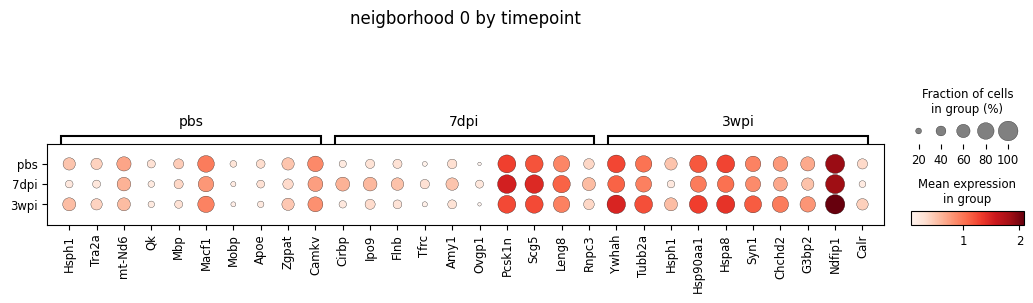

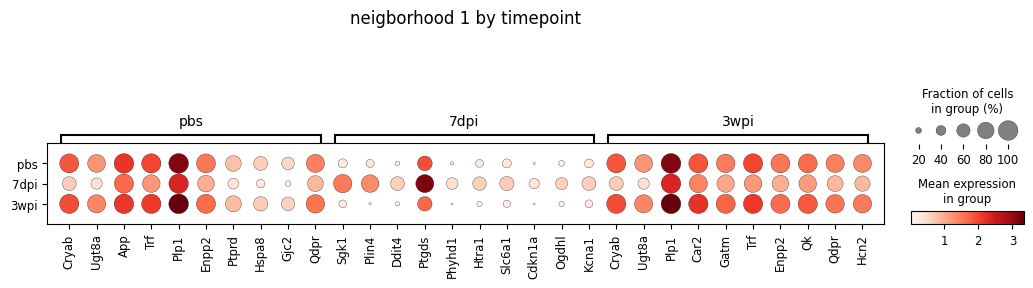

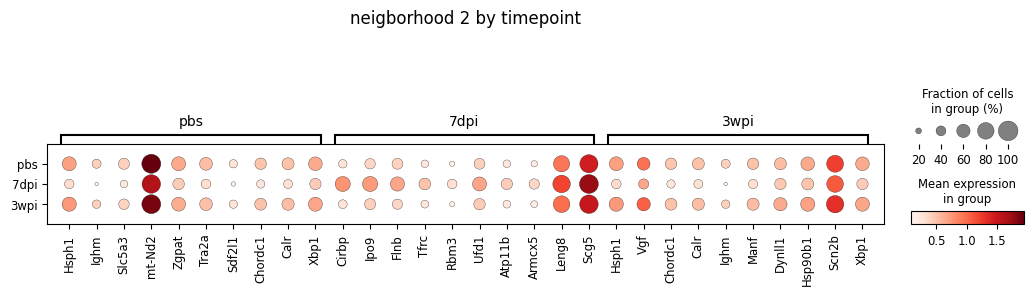

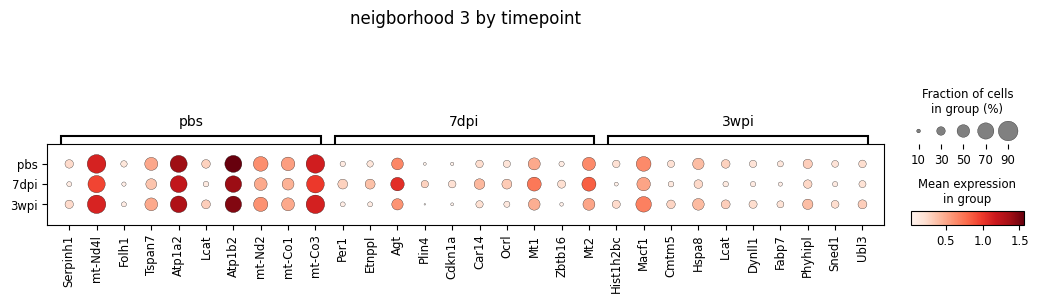

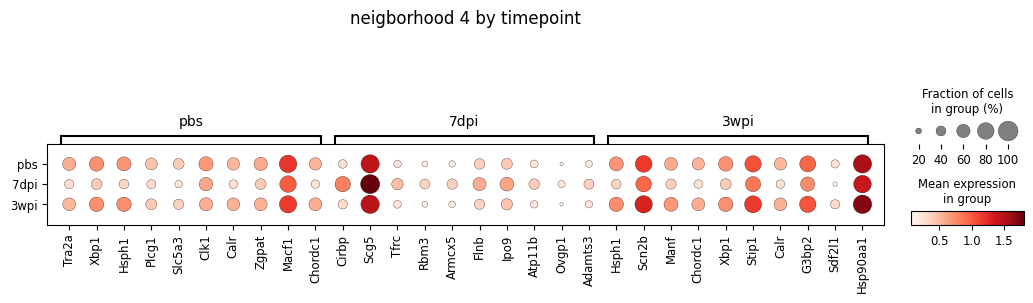

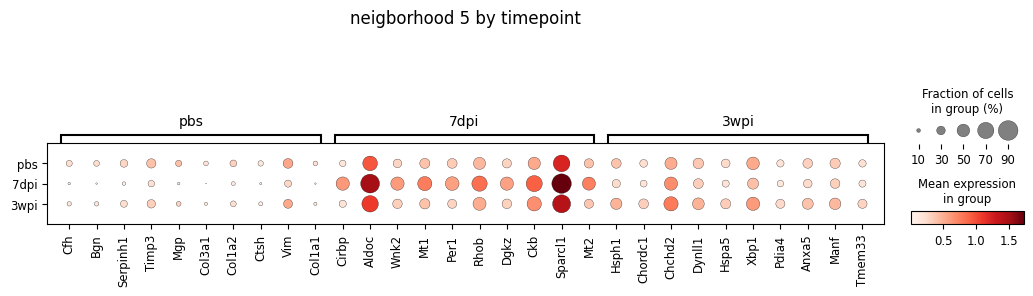

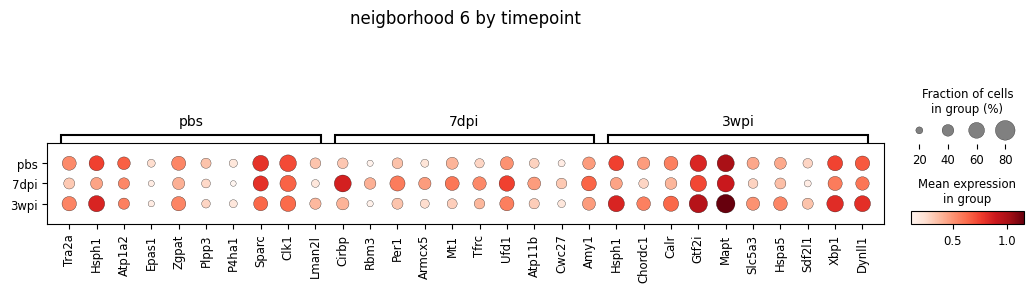

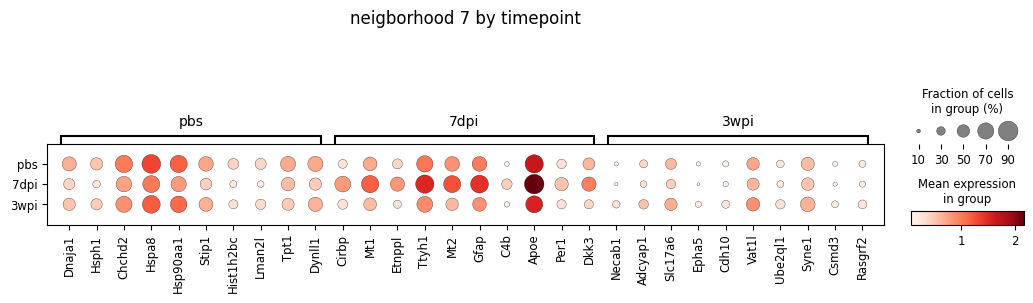

In [ ]:
compare = "timepoint"
cluster = "cellcharter_k8"
key = f"{compare}_DEGs"

for group in adata.obs[cluster].cat.categories:
    subset = adata[adata.obs[cluster] == group]

    sc.tl.rank_genes_groups(
        subset, groupby=compare, method="wilcoxon", layer="normalized", key_added=key
    )

    # sc.pl.rank_genes_groups(subset, key=key)
    sc.pl.rank_genes_groups_dotplot(
        subset,
        groupby=compare,
        n_genes=10,
        layer="normalized",
        title=f"neigborhood {group} by timepoint",
        dendrogram=False,
        key=key,
    )

    # sc.pl.rank_genes_groups_heatmap(
    #     subset,
    #     groupby=compare,
    #     layer="normalized",
    #     dendrogram=False,
    #     cmap="Blues",
    #     key=key,
    # )

    adata.uns[f"neighborhood {group}_{key}"] = subset.uns[key].copy()

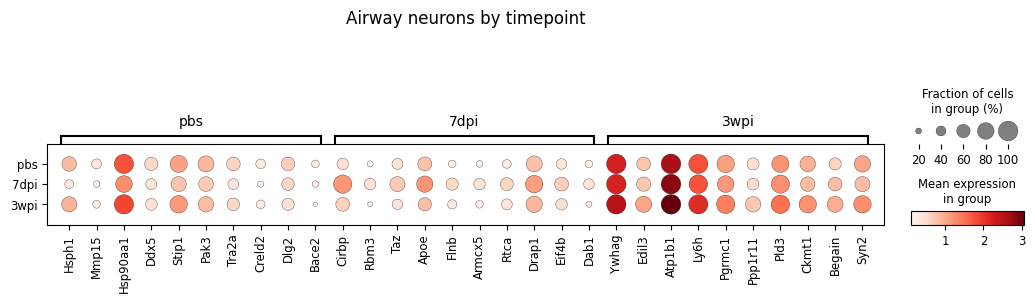

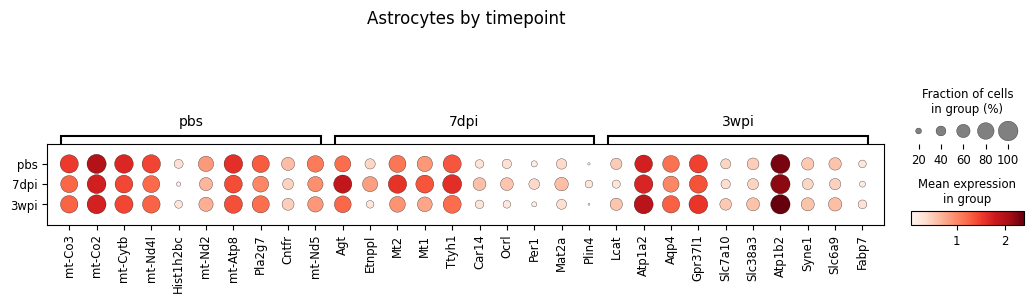

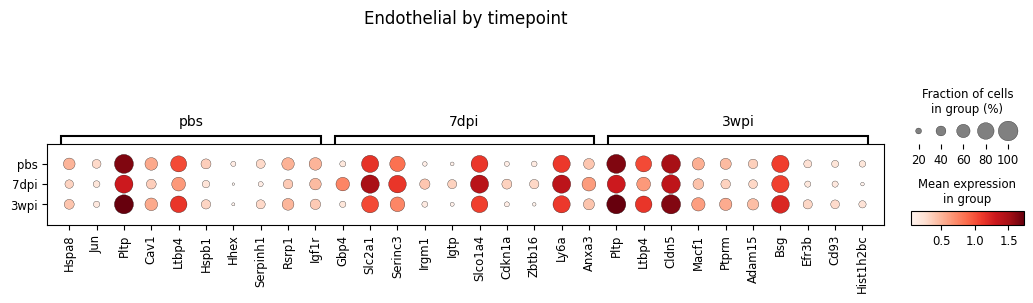

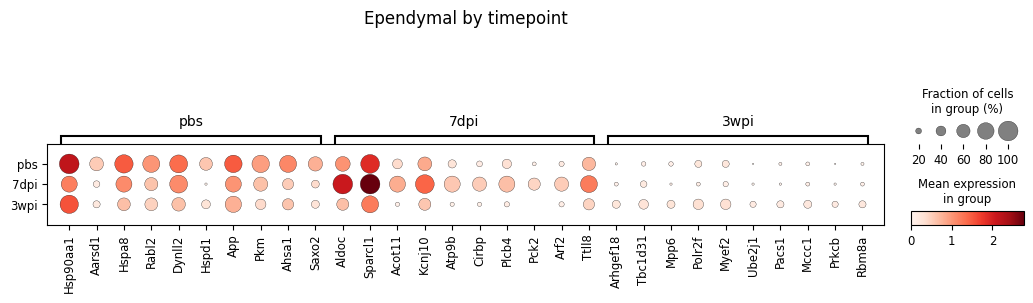

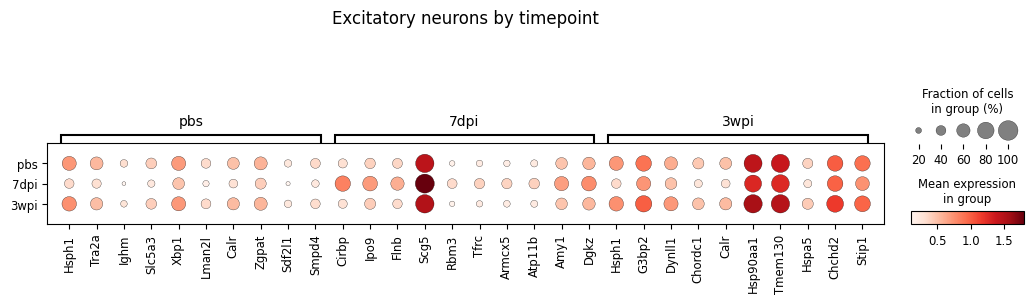

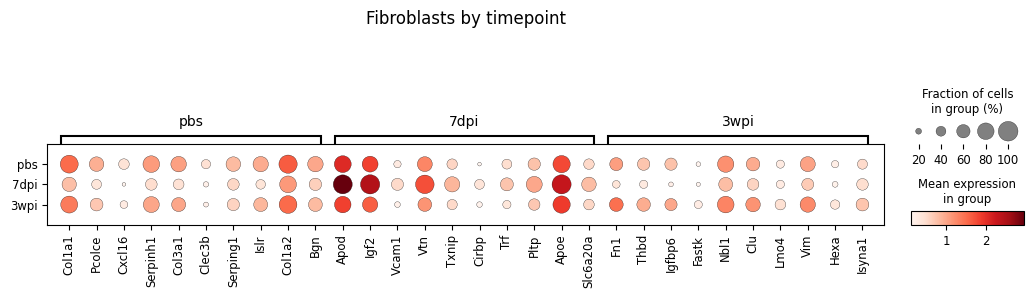

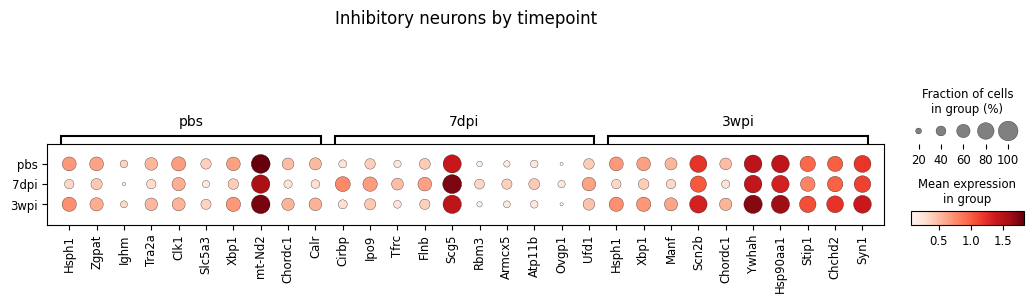

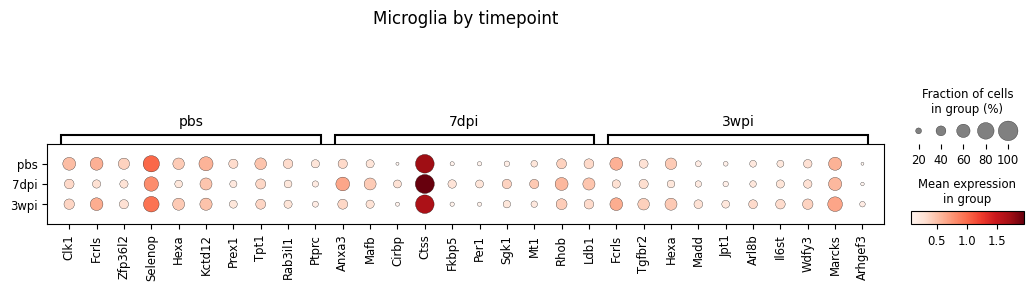

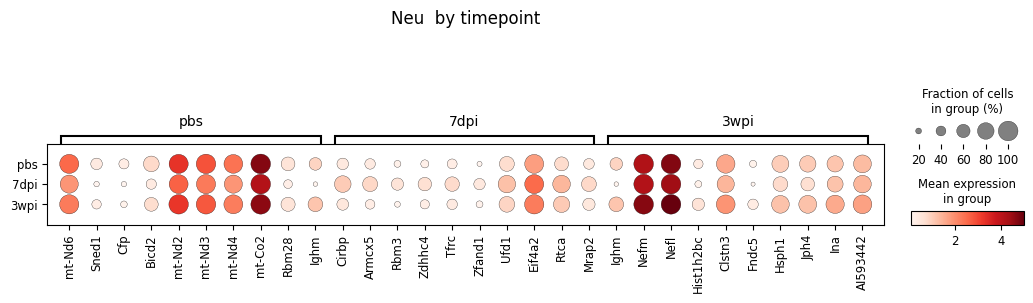

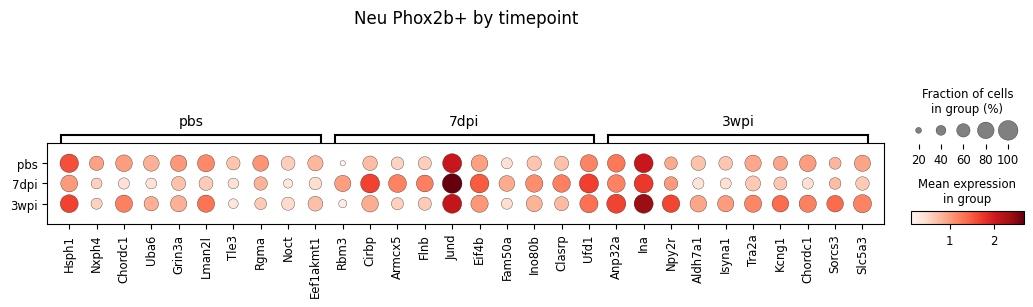

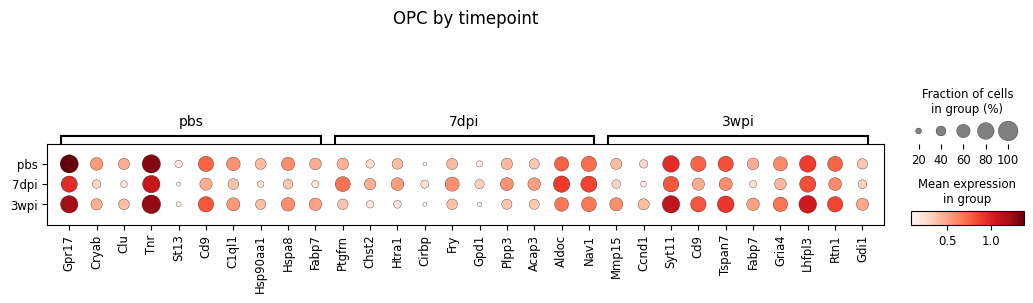

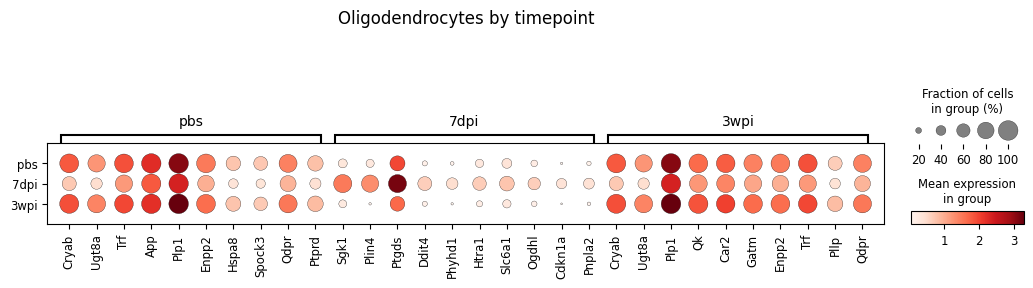

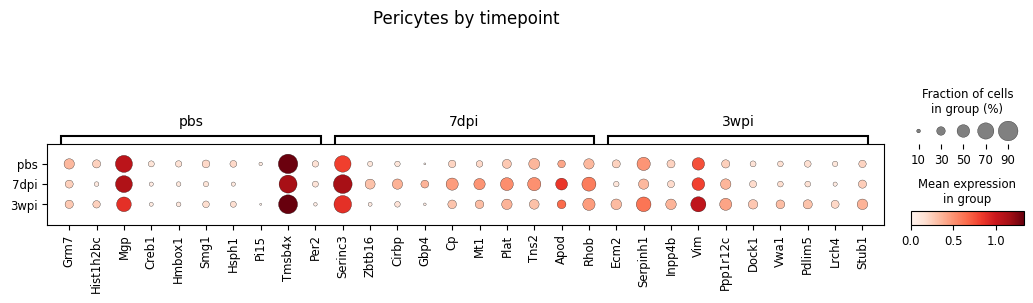

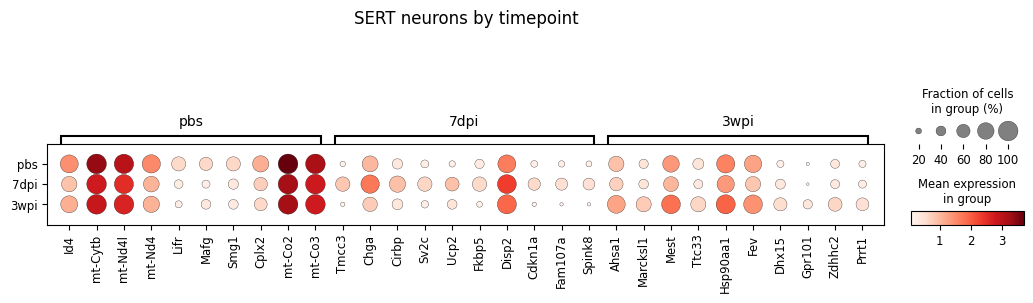

In [22]:
compare = "timepoint"
cluster = "celltype"
key = f"{compare}_DEGs"

for group in adata.obs[cluster].cat.categories:
    subset = adata[adata.obs[cluster] == group]

    sc.tl.rank_genes_groups(
        subset, groupby=compare, method="wilcoxon", layer="normalized", key_added=key
    )

    # sc.pl.rank_genes_groups(subset, key=key)
    sc.pl.rank_genes_groups_dotplot(
        subset,
        groupby=compare,
        n_genes=10,
        layer="normalized",
        title=f"{group} by timepoint",
        dendrogram=False,
        key=key,
    )

    adata.uns[f"{group}_{key}"] = subset.uns[key].copy()

# Save/Load

In [ ]:
adata.write_zarr(DATADIR / "processed" / "external" / "neighborhood_analyzed")

In [4]:
adata = ad.read_zarr(DATADIR / "processed" / "external" / "neighborhood_analyzed")
adata

AnnData object with n_obs × n_vars = 36344 × 19059
    obs: 'batch', 'nCount_RNA', 'nFeature_RNA', 'number_clusters', 'percent.mt', 'log10_nCount_RNA', 'log10_nFeature_RNA', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.2', 'seurat_clusters', 'x', 'y', 'celltype', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.30', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.40', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.50', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.60', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.70', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.80', 'BANKSY_labels_nonspatial_pc30_nc0.00_r0.90', 'BANKSY_labels_nonspatial_pc30_nc0.00_r1.00', 'BANKSY_labels_scaled_gaussian_pc30_nc0.20_r0.30', 'BANKSY_labels_scaled_ga